# Construcción de Autoencoder sin Variables Ambientales
https://catalog.data.gov/dataset/high-resolution-floating-solar-pv-data

## 1- Lectura del Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df_sensores = pd.read_csv('FSEC_Regional_Test_BaseLine_data.csv').drop(['Unnamed: 0'], axis=1)

In [4]:
df_sensores = df_sensores.drop_duplicates()

result = df_sensores.copy()
df_sensores = pd.DataFrame()

# Solamente extraemos los datos que abarcan desde el 01-01-2015 hasta el 01-01-2024
result = result[(result['DAY'] >= 2015001) & (result['DAY'] < 2024001)]

In [5]:
# Visualizamos dataset
display(result)

,DAY,HOUR,SY1VDC,S1S1DC,S1S2DC,SY1VAC,SY1IAC,SY1WAC,SY1VAR,SYS1PF,...,REC2RE,LAMBTA,POAIR1,ICP1JT,ICP2JT,ICP3JT,ICP4JT,ICP5JT,ICP6JT,ICP7JT
525600,2015001,00:00:00,1.4,0.06,0.02,287.0,0.61,-0.7,176.1,-0.01,...,0.0,27.50,0.0,23.33,24.45,24.45,20.77,21.92,20.52,20.77
525601,2015001,00:01:00,1.5,0.06,0.02,286.6,0.61,-0.9,175.6,-0.01,...,0.0,27.50,0.0,23.32,24.52,24.52,20.75,21.91,20.51,20.76
525602,2015001,00:02:00,1.6,0.06,0.02,286.6,0.61,-1.7,175.0,-0.01,...,0.0,27.48,0.0,23.31,24.53,24.53,20.76,21.90,20.50,20.75
525603,2015001,00:03:00,1.6,0.06,0.02,286.5,0.61,-1.1,175.5,-0.01,...,0.0,27.48,0.0,23.31,24.52,24.52,20.75,21.89,20.49,20.75
525604,2015001,00:04:00,1.6,0.06,0.02,286.5,0.61,-1.2,175.5,-0.01,...,0.0,27.47,0.0,23.32,24.51,24.51,20.76,21.88,20.49,20.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5258875,2023365,23:55:00,0.8,0.03,0.03,284.8,2.66,-103.9,748.2,-0.14,...,0.0,128.32,-1.1,14.56,15.38,0.00,0.00,12.90,11.43,11.53
5258876,2023365,23:56:00,0.8,0.03,0.03,285.0,2.68,-104.1,756.7,-0.14,...,0.0,127.77,-1.1,14.55,15.38,0.00,0.00,12.90,11.43,11.53
5258877,2023365,23:57:00,0.8,0.03,0.03,284.8,2.66,-104.0,751.6,-0.14,...,0.0,128.12,-1.1,14.53,15.38,0.00,0.00,12.89,11.42,11.52
5258878,2023365,23:58:00,0.8,0.03,0.03,284.7,2.66,-103.9,749.2,-0.14,...,0.0,127.63,-1.2,14.52,15.38,0.00,0.00,12.89,11.42,11.52


In [6]:
# Guardamos solo los campos que nos interesan para conformar el modelo
result_pvs2 = result[
    [
            'DAY',
            'HOUR',
            'SY2VDC',
            'S2S1DC',
            'S2S2DC',
            'S2VACA',
            'S2WACA',
            'S2PFAV',
            'S2FRQA',
            'MODT09',
            'MODT10',
            'MODT11',
            'MODT12',
            'MODT13',
            'MODT14',
            'MODT16',
            'REC2IR',
            'REC2TE'
    ]
]

result = pd.DataFrame()

In [7]:
# Generamos campo datetime a partir del día y la hora
result_pvs2['datetime'] = (
    pd.to_datetime(result_pvs2['DAY'].astype(str), format='%Y%j')
    + pd.to_timedelta(result_pvs2['HOUR'])
)

In [8]:
# Visualizamos dataset resultante
result_pvs2.head(10)

,DAY,HOUR,SY2VDC,S2S1DC,S2S2DC,S2VACA,S2WACA,S2PFAV,S2FRQA,MODT09,MODT10,MODT11,MODT12,MODT13,MODT14,MODT16,REC2IR,REC2TE,datetime
525600,2015001,00:00:00,1.2,0.03,-0.01,284.8,-2.1,-0.01,59.97,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,0.0,0.0,2015-01-01 00:00:00
525601,2015001,00:01:00,1.2,0.03,-0.01,284.8,-2.1,-0.01,59.98,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,0.0,0.0,2015-01-01 00:01:00
525602,2015001,00:02:00,1.2,0.03,-0.01,284.7,-2.1,-0.01,59.97,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,0.0,0.0,2015-01-01 00:02:00
525603,2015001,00:03:00,1.2,0.03,-0.01,284.7,-2.0,-0.01,59.97,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,0.0,0.0,2015-01-01 00:03:00
525604,2015001,00:04:00,1.4,0.03,-0.01,284.8,-2.2,-0.01,59.96,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,0.0,0.0,2015-01-01 00:04:00
525605,2015001,00:05:00,1.4,0.03,-0.01,284.5,-2.2,-0.01,59.97,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,0.0,0.0,2015-01-01 00:05:00
525606,2015001,00:06:00,1.5,0.03,-0.01,284.6,-2.2,-0.01,59.97,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,0.0,0.0,2015-01-01 00:06:00
525607,2015001,00:07:00,1.5,0.03,-0.01,284.7,-2.1,-0.01,59.97,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,0.0,0.0,2015-01-01 00:07:00
525608,2015001,00:08:00,1.4,0.03,-0.01,284.8,-2.1,-0.01,59.97,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,0.0,0.0,2015-01-01 00:08:00
525609,2015001,00:09:00,1.4,0.03,-0.01,284.9,-2.2,-0.01,59.97,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,0.0,0.0,2015-01-01 00:09:00


Se detectan outliers que deben de ser tratados

## 2- Preparación del Dataset

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

**1. FEATURE ENGINEERING**

In [11]:
# Creamos variables temporales cíclicas
# No metemos la fecha como número directo porque el modelo podría interpretar mal la distancia entre horas o días.
# Por ejemplo, las 23:59 y las 00:00 son cercanas, pero numéricamente parecen lejanas. Por eso se decide usar seno y coseno.

result_pvs2["hour_decimal"] = (
    result_pvs2["datetime"].dt.hour
    + result_pvs2["datetime"].dt.minute / 60
    + result_pvs2["datetime"].dt.second / 3600
)

result_pvs2["dayofyear"] = result_pvs2["datetime"].dt.dayofyear

result_pvs2["hour_sin"] = np.sin(2 * np.pi * result_pvs2["hour_decimal"] / 24)
result_pvs2["hour_cos"] = np.cos(2 * np.pi * result_pvs2["hour_decimal"] / 24)

result_pvs2["doy_sin"] = np.sin(2 * np.pi * result_pvs2["dayofyear"] / 365.25)
result_pvs2["doy_cos"] = np.cos(2 * np.pi * result_pvs2["dayofyear"] / 365.25)

In [12]:
result_pvs2

,DAY,HOUR,SY2VDC,S2S1DC,S2S2DC,S2VACA,S2WACA,S2PFAV,S2FRQA,MODT09,...,MODT16,REC2IR,REC2TE,datetime,hour_decimal,dayofyear,hour_sin,hour_cos,doy_sin,doy_cos
525600,2015001,00:00:00,1.2,0.03,-0.01,284.8,-2.1,-0.01,59.97,32767.00,...,32767.00,0.0,0.0,2015-01-01 00:00:00,0.000000,1,0.000000,1.000000,0.017202,0.999852
525601,2015001,00:01:00,1.2,0.03,-0.01,284.8,-2.1,-0.01,59.98,32767.00,...,32767.00,0.0,0.0,2015-01-01 00:01:00,0.016667,1,0.004363,0.999990,0.017202,0.999852
525602,2015001,00:02:00,1.2,0.03,-0.01,284.7,-2.1,-0.01,59.97,32767.00,...,32767.00,0.0,0.0,2015-01-01 00:02:00,0.033333,1,0.008727,0.999962,0.017202,0.999852
525603,2015001,00:03:00,1.2,0.03,-0.01,284.7,-2.0,-0.01,59.97,32767.00,...,32767.00,0.0,0.0,2015-01-01 00:03:00,0.050000,1,0.013090,0.999914,0.017202,0.999852
525604,2015001,00:04:00,1.4,0.03,-0.01,284.8,-2.2,-0.01,59.96,32767.00,...,32767.00,0.0,0.0,2015-01-01 00:04:00,0.066667,1,0.017452,0.999848,0.017202,0.999852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5258875,2023365,23:55:00,0.6,-0.01,-0.01,283.5,-96.7,-0.14,60.00,24.76,...,7.60,0.0,32767.0,2023-12-31 23:55:00,23.916667,365,-0.021815,0.999762,-0.004301,0.999991
5258876,2023365,23:56:00,0.8,-0.01,-0.01,283.5,-96.7,-0.14,60.02,24.75,...,7.59,0.0,32767.0,2023-12-31 23:56:00,23.933333,365,-0.017452,0.999848,-0.004301,0.999991
5258877,2023365,23:57:00,0.8,0.00,-0.01,283.6,-96.9,-0.14,60.01,24.73,...,7.60,0.0,32767.0,2023-12-31 23:57:00,23.950000,365,-0.013090,0.999914,-0.004301,0.999991
5258878,2023365,23:58:00,0.8,0.01,-0.01,283.6,-96.9,-0.14,60.00,24.72,...,7.59,0.0,32767.0,2023-12-31 23:58:00,23.966667,365,-0.008727,0.999962,-0.004301,0.999991


**2. LIMPIEZA DE VALORES ERRÓNEOS O AUSENTES**

In [13]:
# Selección de variables para el autoencoder
numeric_features = [
    'SY2VDC',
    'S2S1DC',
    'S2S2DC',
    'S2VACA',
    'S2WACA',
    'S2PFAV',
    'S2FRQA',
    'MODT09',
    'MODT10',
    'MODT11',
    'MODT12',
    'MODT13',
    'MODT14',
    'MODT16',
    'REC2IR',
    'REC2TE',
    'hour_sin',
    'hour_cos',
    'doy_sin',
    'doy_cos'
]

# Convertir todas las variables a numéricas
for col in numeric_features:
    result_pvs2[col] = pd.to_numeric(result_pvs2[col], errors="coerce")

# Reemplazar infinitos por NaN
result_pvs2[numeric_features] = result_pvs2[numeric_features].replace([np.inf, -np.inf], np.nan)

# Interpolación temporal sencilla
result_pvs2[numeric_features] = result_pvs2[numeric_features].interpolate(method="linear", limit_direction="both")

# Si queda algún NaN, se elimina
result_pvs2 = result_pvs2.dropna(subset=numeric_features).reset_index(drop=True)

# Imprimimos resultado
print(result_pvs2[numeric_features].isna().sum())
print(result_pvs2.shape)

SY2VDC      0
S2S1DC      0
S2S2DC      0
S2VACA      0
S2WACA      0
S2PFAV      0
S2FRQA      0
MODT09      0
MODT10      0
MODT11      0
MODT12      0
MODT13      0
MODT14      0
MODT16      0
REC2IR      0
REC2TE      0
hour_sin    0
hour_cos    0
doy_sin     0
doy_cos     0
dtype: int64
(4733280, 25)


**3. DETECCIÓN DE OUTLIERS**

In [14]:
# Definir límites físicos en variables eléctricas e irradiancia
PHYSICAL_LIMITS = {
    # Variables eléctricas DC
    "SY2VDC": {
        "min": -5,
        "max": 1000,
        "reason": "Tensión DC fuera de rango físico esperado"
    },
    "S2S1DC": {
        "min": -1,
        "max": 50,
        "reason": "Corriente DC string 1 fuera de rango físico esperado"
    },
    "S2S2DC": {
        "min": -1,
        "max": 50,
        "reason": "Corriente DC string 2 fuera de rango físico esperado"
    },

    # Variables eléctricas AC
    "S2VACA": {
        "min": 0,
        "max": 400,
        "reason": "Tensión AC fuera de rango físico esperado"
    },
    "S2WACA": {
        "min": -5000,
        "max": 1e7,
        "reason": "Potencia AC fuera de rango físico esperado"
    },
    "S2PFAV": {
        "min": -1.05,
        "max": 1.05,
        "reason": "Factor de potencia fuera del intervalo físico [-1, 1]"
    },
    "S2FRQA": {
        "min": GRID_FREQUENCY_HZ - 5,
        "max": GRID_FREQUENCY_HZ + 5,
        "reason": "Frecuencia AC fuera de rango físico esperado"
    },

    # Irradiancia
    "REC2IR": {
        "min": -20,
        "max": 1400,
        "reason": "Irradiancia de célula de referencia fuera de rango físico esperado"
    }
}    

# Definir frecuencia
GRID_FREQUENCY_HZ = 60 # Red de EEUU, por lo tanto, de 60 Hz

# Definir límites para las temperaturas de módulo
MODULE_TEMP_COLUMNS = [
        "MODT09", "MODT10", "MODT11", "MODT12",'MODT13','MODT14','MODT16' #, "MODT15"
    ]

for col in MODULE_TEMP_COLUMNS:
    PHYSICAL_LIMITS[col] = {
        "min": -100,
        "max": 10000,
        "reason": "Temperatura de módulo FV fuera de rango físico esperado"
    }

In [15]:
# Función para detectar valores imposibles
def flag_impossible_values(df, physical_limits):
    df = df.copy()

    df["has_impossible_value"] = False
    df["n_impossible_values"] = 0
    df["impossible_reasons"] = ""

    summary_rows = []

    for col, limits in physical_limits.items():

        if col not in df.columns:
            print(f"AVISO: la columna {col} no existe en el DataFrame.")
            continue

        min_val = limits.get("min", None)
        max_val = limits.get("max", None)
        reason = limits.get("reason", "Valor físicamente imposible")

        # Aseguramos formato numérico
        df[col] = pd.to_numeric(df[col], errors="coerce")

        condition = pd.Series(False, index=df.index)

        # Valores NaN o infinitos no se consideran outliers físicos aquí. Han sido tratados previamente.
        finite_mask = np.isfinite(df[col])

        if min_val is not None:
            condition = condition | (finite_mask & (df[col] < min_val))

        if max_val is not None:
            condition = condition | (finite_mask & (df[col] > max_val))

        flag_col = f"impossible_{col}"
        df[flag_col] = condition

        df.loc[condition, "has_impossible_value"] = True
        df.loc[condition, "n_impossible_values"] += 1
        df.loc[condition, "impossible_reasons"] += f"{col}: {reason}; "

        summary_rows.append({
            "variable": col,
            "min_allowed": min_val,
            "max_allowed": max_val,
            "n_impossible": int(condition.sum()),
            "percentage_impossible": 100 * condition.mean()
        })

    summary = pd.DataFrame(summary_rows)

    return df, summary

In [16]:
# Aplicar función para detección de outliers
df_checked, impossible_summary = flag_impossible_values(
    result_pvs2,
    PHYSICAL_LIMITS
)

impossible_summary.sort_values(
    "n_impossible",
    ascending=False
)

print("Filas totales:", len(df_checked))
print("Filas con algún valor imposible:", df_checked["has_impossible_value"].sum())
print(
    "Porcentaje:",
    100 * df_checked["has_impossible_value"].mean()
)

Filas totales: 4733280
Filas con algún valor imposible: 1354964
Porcentaje: 28.626322550113244


In [17]:
cols_review = [
    "datetime",
    "has_impossible_value",
    "n_impossible_values",
    "impossible_reasons",
    'SY2VDC',
    'S2S1DC',
    'S2S2DC',
    'S2VACA',
    'S2WACA',
    'S2PFAV',
    'S2FRQA',
    'REC2IR',
    'MODT09',
    'MODT10',
    'MODT11',
    'MODT12',
    'MODT13',
    'MODT14',
    'MODT16'
]

df_checked[df_checked["has_impossible_value"]][cols_review].head(20)

,datetime,has_impossible_value,n_impossible_values,impossible_reasons,SY2VDC,S2S1DC,S2S2DC,S2VACA,S2WACA,S2PFAV,S2FRQA,REC2IR,MODT09,MODT10,MODT11,MODT12,MODT13,MODT14,MODT16
0,2015-01-01 00:00:00,True,7,MODT09: Temperatura de módulo FV fuera de rang...,1.2,0.03,-0.01,284.8,-2.1,-0.01,59.97,0.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
1,2015-01-01 00:01:00,True,7,MODT09: Temperatura de módulo FV fuera de rang...,1.2,0.03,-0.01,284.8,-2.1,-0.01,59.98,0.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
2,2015-01-01 00:02:00,True,7,MODT09: Temperatura de módulo FV fuera de rang...,1.2,0.03,-0.01,284.7,-2.1,-0.01,59.97,0.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
3,2015-01-01 00:03:00,True,7,MODT09: Temperatura de módulo FV fuera de rang...,1.2,0.03,-0.01,284.7,-2.0,-0.01,59.97,0.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
4,2015-01-01 00:04:00,True,7,MODT09: Temperatura de módulo FV fuera de rang...,1.4,0.03,-0.01,284.8,-2.2,-0.01,59.96,0.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
5,2015-01-01 00:05:00,True,7,MODT09: Temperatura de módulo FV fuera de rang...,1.4,0.03,-0.01,284.5,-2.2,-0.01,59.97,0.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
6,2015-01-01 00:06:00,True,7,MODT09: Temperatura de módulo FV fuera de rang...,1.5,0.03,-0.01,284.6,-2.2,-0.01,59.97,0.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
7,2015-01-01 00:07:00,True,7,MODT09: Temperatura de módulo FV fuera de rang...,1.5,0.03,-0.01,284.7,-2.1,-0.01,59.97,0.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
8,2015-01-01 00:08:00,True,7,MODT09: Temperatura de módulo FV fuera de rang...,1.4,0.03,-0.01,284.8,-2.1,-0.01,59.97,0.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
9,2015-01-01 00:09:00,True,7,MODT09: Temperatura de módulo FV fuera de rang...,1.4,0.03,-0.01,284.9,-2.2,-0.01,59.97,0.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0


**4. FILTRADO DE HORAS ÚTILES**

In [18]:
# Para detectar anomalías, no interesa entrenar series temporales con noche completa.
# Se decide definir como registros evaluables aquellos con irradiancia suficiente.
IRRADIANCE_THRESHOLD = 50  # W/m2 --> umbral razonable inicial

df_model = df_checked.copy()
df_model["is_daylight"] = (
    (df_model["REC2IR"] > IRRADIANCE_THRESHOLD)
)

df_model = df_model[df_model["is_daylight"]].copy()
df_model = df_model.sort_values("datetime").reset_index(drop=True)

print("Filas originales:", len(result_pvs2))
print("Filas con irradiancia suficiente:", len(df_model))

Filas originales: 4733280
Filas con irradiancia suficiente: 2118614


In [19]:
result_pvs2 = pd.DataFrame()

# Mostramos dataset final
df_model

,DAY,HOUR,SY2VDC,S2S1DC,S2S2DC,S2VACA,S2WACA,S2PFAV,S2FRQA,MODT09,...,impossible_S2FRQA,impossible_REC2IR,impossible_MODT09,impossible_MODT10,impossible_MODT11,impossible_MODT12,impossible_MODT13,impossible_MODT14,impossible_MODT16,is_daylight
0,2015001,07:46:00,379.6,0.33,-0.01,284.1,77.4,0.15,60.00,32767.00,...,False,False,True,True,True,True,True,True,True,True
1,2015001,07:47:00,377.4,0.35,-0.01,284.0,87.1,0.17,59.99,32767.00,...,False,False,True,True,True,True,True,True,True,True
2,2015001,07:48:00,381.8,0.37,-0.01,283.9,93.6,0.19,60.00,32767.00,...,False,False,True,True,True,True,True,True,True,True
3,2015001,07:49:00,385.4,0.37,-0.01,284.1,94.7,0.19,59.99,32767.00,...,False,False,True,True,True,True,True,True,True,True
4,2015001,07:50:00,397.2,0.40,-0.01,284.2,109.5,0.22,59.99,32767.00,...,False,False,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2118609,2023365,16:45:00,149.8,0.54,-0.01,282.9,-39.1,-0.06,59.98,39.45,...,False,False,False,False,False,False,False,False,False,True
2118610,2023365,16:46:00,185.4,0.42,-0.01,282.7,-43.4,-0.06,60.01,38.93,...,False,False,False,False,False,False,False,False,False,True
2118611,2023365,16:47:00,222.1,0.38,-0.01,282.7,-38.2,-0.06,60.00,38.46,...,False,False,False,False,False,False,False,False,False,True
2118612,2023365,16:48:00,258.8,0.36,-0.01,283.0,-29.8,-0.04,59.98,38.11,...,False,False,False,False,False,False,False,False,False,True


## 3- Entrenamiento del Modelo

**1. DIVISIÓN TRAIN / VALIDATION / TEST**

In [20]:
# No usamos train_test_split aleatorio. En series temporales conviene respetar el orden.
# Para quitar outliers durante el entrenamiento separamos primero train y val de test.
# Tras quitar outliers separamos train y val.
df_model = df_model.sort_values("datetime").reset_index(drop=True)

n = len(df_model)

train_val_end = int(n * 0.85)

train_val_df = df_model.iloc[:train_val_end].copy()
test_df = df_model.iloc[train_val_end:].copy()

print("Train + Val:", train_val_df["datetime"].min(), "->", train_val_df["datetime"].max(), train_val_df.shape)
print("Test:", test_df["datetime"].min(), "->", test_df["datetime"].max(), test_df.shape)

Train + Val: 2015-01-01 07:46:00 -> 2022-08-12 17:55:00 (1800821, 44)
Test: 2022-08-12 17:56:00 -> 2023-12-31 16:49:00 (317793, 44)


In [21]:
# Quitar outliers para el entrenamiento y la validación
train_val_df_clean = train_val_df[
    train_val_df["has_impossible_value"] == False
].copy()

print("Filas de entrenamiento y validación originales:", len(train_val_df))
print("Filas de entrenamiento y validación limpias:", len(train_val_df_clean))
print("Filas eliminadas del entrenamiento y validación:", len(train_val_df) - len(train_val_df_clean))

# Mantenemos Outliers de Test y Validation
train_val_df_full = train_val_df.copy()
test_df_full = test_df.copy()

print("Valores imposibles en test:", test_df_full["has_impossible_value"].sum())

Filas de entrenamiento y validación originales: 1800821
Filas de entrenamiento y validación limpias: 1225642
Filas eliminadas del entrenamiento y validación: 575179
Valores imposibles en test: 121190


In [22]:
n = len(train_val_df_clean)
train_end = int(n * 0.75)

train_df_clean = train_val_df_clean.iloc[:train_end].copy()
val_df_clean = train_val_df_clean.iloc[train_end:].copy()

print("Train:", train_df_clean["datetime"].min(), "->", train_df_clean["datetime"].max(), train_df_clean.shape)
print("Val:", val_df_clean["datetime"].min(), "->", val_df_clean["datetime"].max(), val_df_clean.shape)

Train: 2015-04-06 11:09:00 -> 2019-10-10 07:29:00 (919231, 44)
Val: 2019-10-10 07:30:00 -> 2022-08-12 12:04:00 (306411, 44)


In [23]:
# Crear dataset de validación FULL, es decir, con outliers incluidos

val_start_datetime = val_df_clean["datetime"].min()
val_end_datetime = val_df_clean["datetime"].max()

val_df_full = train_val_df_full[
    (train_val_df_full["datetime"] >= val_start_datetime) &
    (train_val_df_full["datetime"] <= val_end_datetime)
].copy()

print("Val clean:", val_df_clean["datetime"].min(), "->", val_df_clean["datetime"].max(), val_df_clean.shape)
print("Val full:", val_df_full["datetime"].min(), "->", val_df_full["datetime"].max(), val_df_full.shape)

print("Valores imposibles en val full:", val_df_full["has_impossible_value"].sum())

Val clean: 2019-10-10 07:30:00 -> 2022-08-12 12:04:00 (306411, 44)
Val full: 2019-10-10 07:30:00 -> 2022-08-12 12:04:00 (695945, 44)
Valores imposibles en val full: 389534


In [24]:
train_df_full = train_val_df_full[
    (train_val_df_full["datetime"] < val_start_datetime)
].copy()

In [25]:
# Vaciar variables para ahorrar espacio
train_df = pd.DataFrame()
val_df = pd.DataFrame()
test_df = pd.DataFrame()

**2. ESCALADO**

In [26]:
# Se emplea RobustScaler porque es menos sensible a outliers que StandardScaler.
# En detección de anomalías esto es importante, porque probablemente existen anomalías dentro del dataset.
scaler = RobustScaler()

X_train_clean = scaler.fit_transform(train_df_clean[numeric_features])
X_val_clean = scaler.transform(val_df_clean[numeric_features])

X_test_full = scaler.transform(test_df_full[numeric_features])

In [27]:
X_train_full = scaler.transform(train_df_full[numeric_features])
X_val_full = scaler.transform(val_df_full[numeric_features])

**3. CONSTRUCCIÓN DEL AUTOENCODER**

In [28]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

tf.keras.backend.clear_session()
tf.random.set_seed(42)

input_dim = X_train_clean.shape[1]

encoding_dim = 12
l2_reg = 1e-5
dropout_rate = 0.10
learning_rate = 3e-4

input_layer = layers.Input(shape=(input_dim,))

# Encoder
x = layers.Dense(
    128,
    activation="elu",
    kernel_regularizer=regularizers.l2(l2_reg)
)(input_layer)

x = layers.BatchNormalization()(x)
x = layers.Dropout(dropout_rate)(x)

x = layers.Dense(
    64,
    activation="elu",
    kernel_regularizer=regularizers.l2(l2_reg)
)(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(dropout_rate)(x)

# Bottleneck
bottleneck = layers.Dense(
    encoding_dim,
    activation="linear",
    name="bottleneck"
)(x)

# Decoder
x = layers.Dense(
    64,
    activation="elu",
    kernel_regularizer=regularizers.l2(l2_reg)
)(bottleneck)

x = layers.BatchNormalization()(x)

x = layers.Dense(
    128,
    activation="elu",
    kernel_regularizer=regularizers.l2(l2_reg)
)(x)

x = layers.BatchNormalization()(x)

output_layer = layers.Dense(input_dim, activation="linear")(x)

autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss=tf.keras.losses.Huber(delta=1.0)
)

autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 20)]              0         
                                                                 
 dense (Dense)               (None, 128)               2688      
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_1 (Batc  (None, 64)               256       
 hNormalization)                                             

**4. ENTRENAMIENTO**

In [29]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    min_delta=1e-5
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = autoencoder.fit(
    X_train_clean,
    X_train_clean,
    validation_data=(X_val_clean, X_val_clean),
    epochs=150,
    batch_size=256,
    shuffle=True,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/150
3591/3591 [==============================] - 27s 7ms/step - loss: 0.0229 - val_loss: 0.0103 - lr: 3.0000e-04
Epoch 2/150
3591/3591 [==============================] - 25s 7ms/step - loss: 0.0106 - val_loss: 0.0069 - lr: 3.0000e-04
Epoch 3/150
3591/3591 [==============================] - 24s 7ms/step - loss: 0.0089 - val_loss: 0.0067 - lr: 3.0000e-04
Epoch 4/150
3591/3591 [==============================] - 25s 7ms/step - loss: 0.0081 - val_loss: 0.0058 - lr: 3.0000e-04
Epoch 5/150
3591/3591 [==============================] - 24s 7ms/step - loss: 0.0075 - val_loss: 0.0054 - lr: 3.0000e-04
Epoch 6/150
3591/3591 [==============================] - 24s 7ms/step - loss: 0.0072 - val_loss: 0.0052 - lr: 3.0000e-04
Epoch 7/150
3591/3591 [==============================] - 24s 7ms/step - loss: 0.0067 - val_loss: 0.0040 - lr: 3.0000e-04
Epoch 8/150
3591/3591 [==============================] - 24s 7ms/step - loss: 0.0062 - val_loss: 0.0036 - lr: 3.0000e-04
Epoch 9/150
3591/3591 [=========

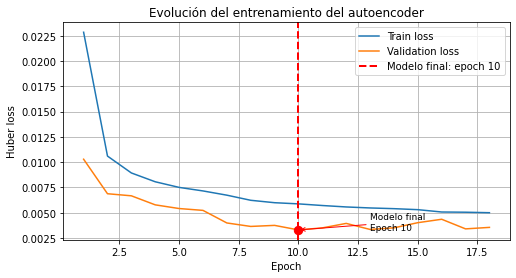

In [101]:
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

# Epoch con mejor val_loss
best_epoch = np.argmin(val_loss) + 1   # +1 porque las epochs se muestran desde 1
best_val_loss = np.min(val_loss)

plt.figure(figsize=(8, 4))

plt.plot(
    range(1, len(train_loss) + 1),
    train_loss,
    label="Train loss"
)

plt.plot(
    range(1, len(val_loss) + 1),
    val_loss,
    label="Validation loss"
)

# Línea vertical en la mejor epoch
plt.axvline(
    x=best_epoch,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Modelo final: epoch {best_epoch}"
)

# Punto sobre la curva de validación
plt.scatter(
    best_epoch,
    best_val_loss,
    color="red",
    s=70,
    zorder=5
)

# Texto explicativo
plt.annotate(
    f"Modelo final\nEpoch {best_epoch}",
    xy=(best_epoch, best_val_loss),
    xytext=(best_epoch + 3, best_val_loss),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=9
)

plt.xlabel("Epoch")
plt.ylabel("Huber loss")
plt.title("Evolución del entrenamiento del autoencoder")
plt.legend()
plt.grid(True)
plt.show()

**5. ERROR DE RECONSTRUCCIÓN**

In [31]:
val_df_full

,DAY,HOUR,SY2VDC,S2S1DC,S2S2DC,S2VACA,S2WACA,S2PFAV,S2FRQA,MODT09,...,impossible_S2FRQA,impossible_REC2IR,impossible_MODT09,impossible_MODT10,impossible_MODT11,impossible_MODT12,impossible_MODT13,impossible_MODT14,impossible_MODT16,is_daylight
1104525,2019283,07:30:00,336.4,1.73,-0.01,280.8,458.8,0.59,60.00,29.34,...,False,False,False,False,False,False,False,False,False,True
1104526,2019283,07:31:00,336.2,1.77,-0.01,281.0,470.9,0.59,59.99,29.57,...,False,False,False,False,False,False,False,False,False,True
1104527,2019283,07:32:00,337.3,1.81,-0.01,280.8,485.5,0.61,60.00,29.87,...,False,False,False,False,False,False,False,False,False,True
1104528,2019283,07:33:00,336.9,1.85,-0.01,280.5,499.6,0.63,60.01,30.35,...,False,False,False,False,False,False,False,False,False,True
1104529,2019283,07:34:00,337.5,1.90,-0.01,280.8,514.7,0.63,60.01,30.87,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1800465,2022224,12:00:00,297.7,5.31,-0.01,287.4,2040.5,0.90,60.01,62.92,...,False,False,False,False,False,False,False,False,False,True
1800466,2022224,12:01:00,299.7,5.32,-0.01,287.2,2050.2,0.90,60.03,62.62,...,False,False,False,False,False,False,False,False,False,True
1800467,2022224,12:02:00,299.3,5.34,-0.01,286.7,2055.3,0.91,60.03,62.61,...,False,False,False,False,False,False,False,False,False,True
1800468,2022224,12:03:00,299.6,5.33,-0.01,286.7,2048.9,0.91,60.02,62.77,...,False,False,False,False,False,False,False,False,False,True


In [32]:
import numpy as np

def reconstruction_error(model, X, delta=1.0):
    X_pred = model.predict(X, verbose=0)
    
    error = X - X_pred
    abs_error = np.abs(error)
    
    huber_error = np.where(
        abs_error <= delta,
        0.5 * error**2,
        delta * (abs_error - 0.5 * delta)
    )
    
    errors = np.mean(huber_error, axis=1)
    
    return errors

train_errors_clean = reconstruction_error(autoencoder, X_train_clean)
train_errors_full = reconstruction_error(autoencoder, X_train_full)

val_errors_clean = reconstruction_error(autoencoder, X_val_clean)
val_errors_full = reconstruction_error(autoencoder, X_val_full)

test_errors = reconstruction_error(autoencoder, X_test_full)


train_df_clean["reconstruction_error"] = train_errors_clean
val_df_clean["reconstruction_error"] = val_errors_clean

train_df_full["reconstruction_error"] = train_errors_full
val_df_full["reconstruction_error"] = val_errors_full
test_df_full["reconstruction_error"] = test_errors

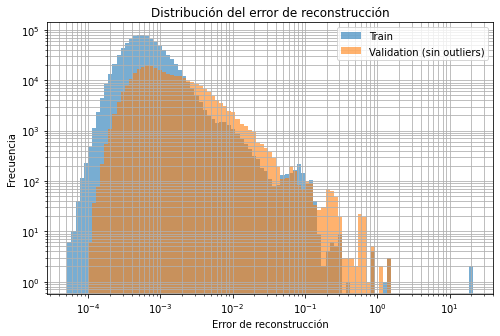

In [33]:
# Evitar problemas con log(0)
train_error_plot = train_errors_clean[train_errors_clean > 0]
val_error_plot = val_errors_clean[val_errors_clean > 0]

# Bins logarítmicos comunes para train y validation
min_error = min(train_error_plot.min(), val_error_plot.min())
max_error = max(train_error_plot.max(), val_error_plot.max())

bins = np.logspace(
    np.log10(min_error),
    np.log10(max_error),
    100
)

plt.figure(figsize=(8, 5))

plt.hist(
    train_error_plot,
    bins=bins,
    alpha=0.6,
    label="Train"
)

plt.hist(
    val_error_plot,
    bins=bins,
    alpha=0.6,
    label="Validation (sin outliers)"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Error de reconstrucción")
plt.ylabel("Frecuencia")
plt.title("Distribución del error de reconstrucción")
plt.legend()
plt.grid(True, which="both")
plt.show()

**6. DEFINIR UMBRAL DE ANOMALÍA**

In [34]:
# Al no tener etiquetas reales de anomalía, definimos el umbral a partir de un percentil alto del error en validación.
# Calcularemos el umbral a partir de los datos de validación SIN OUTLIERS
THRESHOLD_PERCENTILE = 99.9

threshold = np.percentile(val_errors_clean, THRESHOLD_PERCENTILE)

print("Umbral de anomalía:", threshold)

Umbral de anomalía: 0.1559149665552673


**7. DETECCIÓN DE ANOMALÍAS**

In [35]:
train_df_clean["is_anomaly"] = train_df_clean["reconstruction_error"] > threshold
val_df_clean["is_anomaly"] = val_df_clean["reconstruction_error"] > threshold

test_df_full["is_anomaly"] = test_df_full["reconstruction_error"] > threshold

print(test_df_full["is_anomaly"].value_counts())

False    196592
True     121201
Name: is_anomaly, dtype: int64


In [36]:
train_df_full["is_anomaly"] = train_df_full["reconstruction_error"] > threshold

print(train_df_full["is_anomaly"].value_counts())

False    919193
True     185332
Name: is_anomaly, dtype: int64


In [37]:
val_df_full["is_anomaly"] = val_df_full["reconstruction_error"] > threshold

print(val_df_full["is_anomaly"].value_counts())

True     389839
False    306106
Name: is_anomaly, dtype: int64


In [38]:
results_df = test_df_full 
results_df_complete_clean = pd.concat([train_df_clean, val_df_clean, test_df_full], axis=0).sort_values("datetime").reset_index(drop=True)
results_df_complete_full = pd.concat([train_df_full, val_df_full, test_df_full], axis=0).sort_values("datetime").reset_index(drop=True)

## 4- VISUALIZACIÓN DE ANOMALÍAS

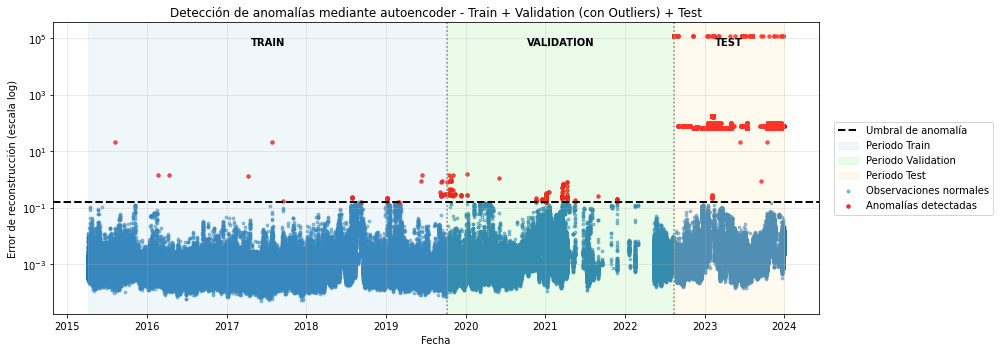

In [39]:
# Asegurar formato datetime
results_df_complete_clean["datetime"] = pd.to_datetime(results_df_complete_clean["datetime"])

# Fechas de partición
train_start = pd.Timestamp("2015-04-06 11:09:00")
train_end   = pd.Timestamp("2019-10-10 07:29:00")

val_start = pd.Timestamp("2019-10-10 07:30:00")
val_end   = pd.Timestamp("2022-08-12 12:04:00")

test_start = pd.Timestamp("2022-08-12 17:56:00")
test_end   = pd.Timestamp("2023-12-31 16:49:00")

fig, ax = plt.subplots(figsize=(14, 5))

# Fondo distinto para cada parte del dataset
ax.axvspan(
    train_start, train_end,
    color="lightblue",
    alpha=0.18,
    label="Periodo Train"
)

ax.axvspan(
    val_start, val_end,
    color="lightgreen",
    alpha=0.18,
    label="Periodo Validation"
)

ax.axvspan(
    test_start, test_end,
    color="moccasin",
    alpha=0.22,
    label="Periodo Test"
)

# Líneas de separación
ax.axvline(train_end, color="gray", linestyle=":", linewidth=1.5)
ax.axvline(val_end, color="gray", linestyle=":", linewidth=1.5)

# Máscaras
normal_points = results_df_complete_clean["is_anomaly"] == False
anomaly_points = results_df_complete_clean["is_anomaly"] == True

# Observaciones normales
ax.scatter(
    results_df_complete_clean.loc[normal_points, "datetime"],
    results_df_complete_clean.loc[normal_points, "reconstruction_error"],
    s=8,
    alpha=0.5,
    label="Observaciones normales"
)

# Anomalías detectadas
ax.scatter(
    results_df_complete_clean.loc[anomaly_points, "datetime"],
    results_df_complete_clean.loc[anomaly_points, "reconstruction_error"],
    s=12,
    color="red",
    alpha=0.8,
    label="Anomalías detectadas"
)

# Umbral
ax.axhline(
    y=threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Umbral de anomalía"
)

# Escala logarítmica
ax.set_yscale("log")

# Etiquetas
ax.set_xlabel("Fecha")
ax.set_ylabel("Error de reconstrucción (escala log)")
ax.set_title("Detección de anomalías mediante autoencoder - Train + Validation (con Outliers) + Test")

# Texto sobre cada zona
ax.text(
    train_start + (train_end - train_start) / 2,
    0.95,
    "TRAIN",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    val_start + (val_end - val_start) / 2,
    0.95,
    "VALIDATION",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    test_start + (test_end - test_start) / 2,
    0.95,
    "TEST",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold"
)

ax.grid(True, which="both", alpha=0.3)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)

plt.tight_layout()
plt.show()

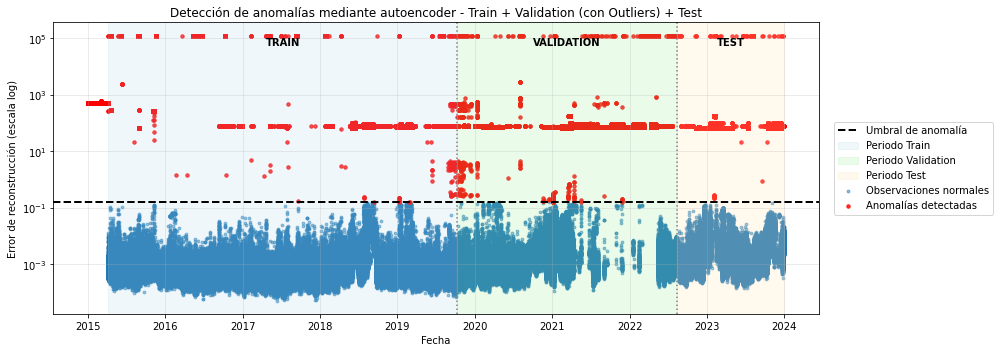

In [40]:
# Asegurar formato datetime
results_df_complete_full["datetime"] = pd.to_datetime(results_df_complete_full["datetime"])

# Fechas de partición
train_start = pd.Timestamp("2015-04-06 11:09:00")
train_end   = pd.Timestamp("2019-10-10 07:29:00")

val_start = pd.Timestamp("2019-10-10 07:30:00")
val_end   = pd.Timestamp("2022-08-12 12:04:00")

test_start = pd.Timestamp("2022-08-12 17:56:00")
test_end   = pd.Timestamp("2023-12-31 16:49:00")

fig, ax = plt.subplots(figsize=(14, 5))

# Fondo distinto para cada parte del dataset
ax.axvspan(
    train_start, train_end,
    color="lightblue",
    alpha=0.18,
    label="Periodo Train"
)

ax.axvspan(
    val_start, val_end,
    color="lightgreen",
    alpha=0.18,
    label="Periodo Validation"
)

ax.axvspan(
    test_start, test_end,
    color="moccasin",
    alpha=0.22,
    label="Periodo Test"
)

# Líneas de separación
ax.axvline(train_end, color="gray", linestyle=":", linewidth=1.5)
ax.axvline(val_end, color="gray", linestyle=":", linewidth=1.5)

# Máscaras
normal_points = results_df_complete_full["is_anomaly"] == False
anomaly_points = results_df_complete_full["is_anomaly"] == True

# Observaciones normales
ax.scatter(
    results_df_complete_full.loc[normal_points, "datetime"],
    results_df_complete_full.loc[normal_points, "reconstruction_error"],
    s=8,
    alpha=0.5,
    label="Observaciones normales"
)

# Anomalías detectadas
ax.scatter(
    results_df_complete_full.loc[anomaly_points, "datetime"],
    results_df_complete_full.loc[anomaly_points, "reconstruction_error"],
    s=12,
    color="red",
    alpha=0.8,
    label="Anomalías detectadas"
)

# Umbral
ax.axhline(
    y=threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Umbral de anomalía"
)

# Escala logarítmica
ax.set_yscale("log")

# Etiquetas
ax.set_xlabel("Fecha")
ax.set_ylabel("Error de reconstrucción (escala log)")
ax.set_title("Detección de anomalías mediante autoencoder - Train + Validation (con Outliers) + Test")

# Texto sobre cada zona
ax.text(
    train_start + (train_end - train_start) / 2,
    0.95,
    "TRAIN",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    val_start + (val_end - val_start) / 2,
    0.95,
    "VALIDATION",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    test_start + (test_end - test_start) / 2,
    0.95,
    "TEST",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold"
)

ax.grid(True, which="both", alpha=0.3)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)

plt.tight_layout()
plt.show()

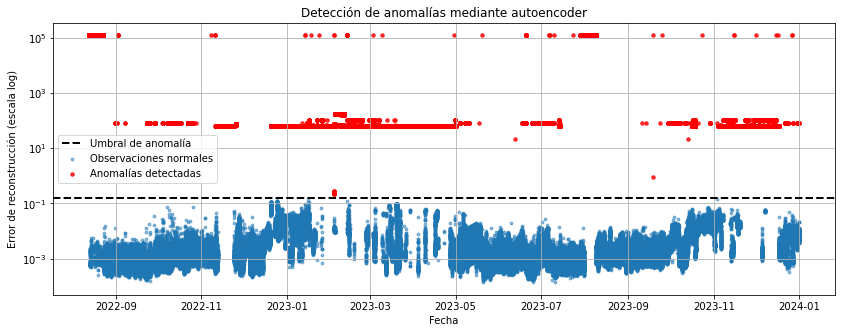

In [41]:
# Visualizar error temporal como nube de puntos en escala logarítmica
plt.figure(figsize=(14, 5))

# Máscaras
normal_points = results_df["is_anomaly"] == False
anomaly_points = results_df["is_anomaly"] == True

# Puntos normales
plt.scatter(
    results_df.loc[normal_points, "datetime"],
    results_df.loc[normal_points, "reconstruction_error"],
    s=8,
    alpha=0.5,
    label="Observaciones normales"
)

# Anomalías
plt.scatter(
    results_df.loc[anomaly_points, "datetime"],
    results_df.loc[anomaly_points, "reconstruction_error"],
    s=12,
    color="red",
    alpha=0.8,
    label="Anomalías detectadas"
)

# Umbral
plt.axhline(
    y=threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Umbral de anomalía"
)

plt.yscale("log")

plt.xlabel("Fecha")
plt.ylabel("Error de reconstrucción (escala log)")
plt.title("Detección de anomalías mediante autoencoder")
plt.legend()
plt.grid(True, which="both")
plt.show()

## 5- CLUSTERIZACIÓN DE ANOMALÍAS

In [104]:
val_df_full

,DAY,HOUR,SY2VDC,S2S1DC,S2S2DC,S2VACA,S2WACA,S2PFAV,S2FRQA,MODT09,...,impossible_MODT09,impossible_MODT10,impossible_MODT11,impossible_MODT12,impossible_MODT13,impossible_MODT14,impossible_MODT16,is_daylight,reconstruction_error,is_anomaly
1104525,2019283,07:30:00,336.4,1.73,-0.01,280.8,458.8,0.59,60.00,29.34,...,False,False,False,False,False,False,False,True,0.000824,False
1104526,2019283,07:31:00,336.2,1.77,-0.01,281.0,470.9,0.59,59.99,29.57,...,False,False,False,False,False,False,False,True,0.000815,False
1104527,2019283,07:32:00,337.3,1.81,-0.01,280.8,485.5,0.61,60.00,29.87,...,False,False,False,False,False,False,False,True,0.000819,False
1104528,2019283,07:33:00,336.9,1.85,-0.01,280.5,499.6,0.63,60.01,30.35,...,False,False,False,False,False,False,False,True,0.000847,False
1104529,2019283,07:34:00,337.5,1.90,-0.01,280.8,514.7,0.63,60.01,30.87,...,False,False,False,False,False,False,False,True,0.000889,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1800465,2022224,12:00:00,297.7,5.31,-0.01,287.4,2040.5,0.90,60.01,62.92,...,False,False,False,False,False,False,False,True,0.004739,False
1800466,2022224,12:01:00,299.7,5.32,-0.01,287.2,2050.2,0.90,60.03,62.62,...,False,False,False,False,False,False,False,True,0.005089,False
1800467,2022224,12:02:00,299.3,5.34,-0.01,286.7,2055.3,0.91,60.03,62.61,...,False,False,False,False,False,False,False,True,0.005164,False
1800468,2022224,12:03:00,299.6,5.33,-0.01,286.7,2048.9,0.91,60.02,62.77,...,False,False,False,False,False,False,False,True,0.004776,False


In [105]:
# 1. Calcular error por variable
# Concatenamos los datos escalados en el mismo orden que train_df
# Inicialmente se había incluido los train, val y test y se ha mantenido la estructura de código
X_all_full = np.vstack([
    X_train_full
])

# Concatenamos el dataframe en el mismo orden
# Inicialmente se había incluido los train, val y test y se ha mantenido la estructura de código
all_df =(train_df_full 
).reset_index(drop=True)

# Reconstrucción del autoencoder
X_all_pred = autoencoder.predict(X_all_full, verbose=0)

# Error Huber por variable
error = X_all_full - X_all_pred
abs_error = np.abs(error)
delta = 1.0

errors_by_var = np.where(
    abs_error <= delta,
    0.5 * error**2,
    delta * (abs_error - 0.5 * delta)
)

error_cols = [f"error_{col}" for col in numeric_features]

errors_by_var_df = pd.DataFrame(
    errors_by_var,
    columns=error_cols
)

# Dataset completo con errores por variable
results_cluster_df = pd.concat(
    [all_df, errors_by_var_df],
    axis=1
)

# Orden temporal
results_cluster_df = results_cluster_df.sort_values("datetime").reset_index(drop=True)


In [106]:
# 2. Seleccionar solo las anomalías
anomalies_df = results_cluster_df[
    results_cluster_df["is_anomaly"] == True
].copy()

print("Número de anomalías:", len(anomalies_df))

Número de anomalías: 185332


In [107]:
# 3. Preparar los datos para K-Means
# No se va a usar directamente las variables originales, sino los errores por variable.
from sklearn.preprocessing import StandardScaler

X_anomalies_errors = anomalies_df[error_cols].copy()

# Transformación logarítmica para reducir el efecto de errores extremadamente altos
X_anomalies_errors = np.log1p(X_anomalies_errors)

# Escalado previo a K-Means
scaler_kmeans = StandardScaler()
X_anomalies_errors = scaler_kmeans.fit_transform(X_anomalies_errors)

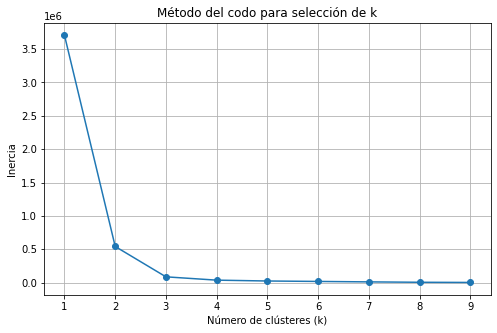

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 4.1. Método del codo para seleccionar número de clústeres
k_values = range(1, 10)
inertias = []

for k in k_values:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans_temp.fit(X_anomalies_errors)
    inertias.append(kmeans_temp.inertia_)

# Representación gráfica
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Inercia")
plt.title("Método del codo para selección de k")
plt.grid(True)
plt.show()

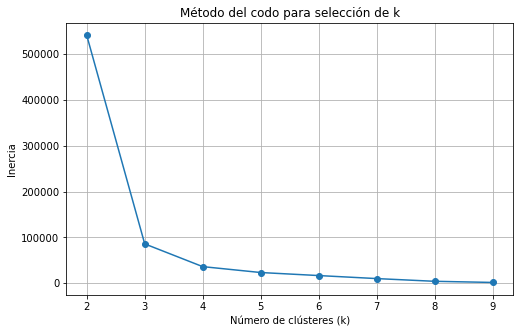

In [110]:
# 4.2. Método del codo para seleccionar número de clústeres (estrechamos el rango para una mejor visualización)

k_values = range(2, 10)
inertias = []

for k in k_values:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans_temp.fit(X_anomalies_errors)
    inertias.append(kmeans_temp.inertia_)

# Representación gráfica
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Inercia")
plt.title("Método del codo para selección de k")
plt.grid(True)
plt.show()

In [199]:
# 5. Aplicar K-Means para detección de outliers
k = 4
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

anomalies_df["error_cluster"] = kmeans.fit_predict(X_anomalies_errors)

In [200]:
anomalies_df["error_cluster"].value_counts().sort_index()

0    39576
1    51760
2    55552
3    38444
Name: error_cluster, dtype: int64

In [201]:
# 6. Incorporar a Dataset Completo
results_cluster_df["error_cluster"] = np.nan

results_cluster_df.loc[
    results_cluster_df["is_anomaly"] == True,
    "error_cluster"
] = anomalies_df["error_cluster"].values

In [202]:
# 7. Interpretar cada cluster
# Mirar qué variables tienen mayor error medio dentro de cada cluster
cluster_profile = anomalies_df.groupby("error_cluster")[error_cols].mean()

for cluster_id in sorted(anomalies_df["error_cluster"].unique()):
    print(f"\nCluster {cluster_id}")

    top_errors = (
        cluster_profile
        .loc[cluster_id]
        .sort_values(ascending=False)
        .head(10)
    )

    # Quitar prefijo "error_" para que sea más legible
    top_errors.index = top_errors.index.str.replace("error_", "", regex=False)

    print(top_errors)


Cluster 0
MODT10      533.840932
SY2VDC      194.769041
MODT12      120.061097
hour_sin     79.100481
MODT09       75.329098
REC2IR       58.951761
hour_cos     49.225272
S2FRQA       41.199021
doy_cos      35.106294
REC2TE       34.783696
Name: 0, dtype: float64

Cluster 1
S2FRQA      1.260835e+06
SY2VDC      4.097558e+05
MODT10      1.540172e+05
S2PFAV      1.295127e+05
S2S1DC      1.260375e+05
S2S2DC      5.523479e+04
MODT12      4.702799e+04
MODT14      4.338580e+04
S2WACA      3.237717e+04
hour_cos    3.022569e+04
Name: 1, dtype: float64

Cluster 2
MODT11     1405.154546
MODT13     1344.861236
MODT14     1343.395863
MODT16      995.495100
SY2VDC      927.075528
REC2TE      923.376053
MODT10      787.011852
MODT12      503.733844
doy_sin     311.785987
S2VACA      208.696862
Name: 2, dtype: float64

Cluster 3
MODT12    467.064536
MODT09    282.613639
SY2VDC    121.648682
S2FRQA     97.998519
S2PFAV     89.140361
MODT10     81.112762
MODT11     69.580219
MODT13     65.863025
MODT14

## 5- VISUALIZACIÓN DE ANOMALÍAS CLUSTERIZADAS

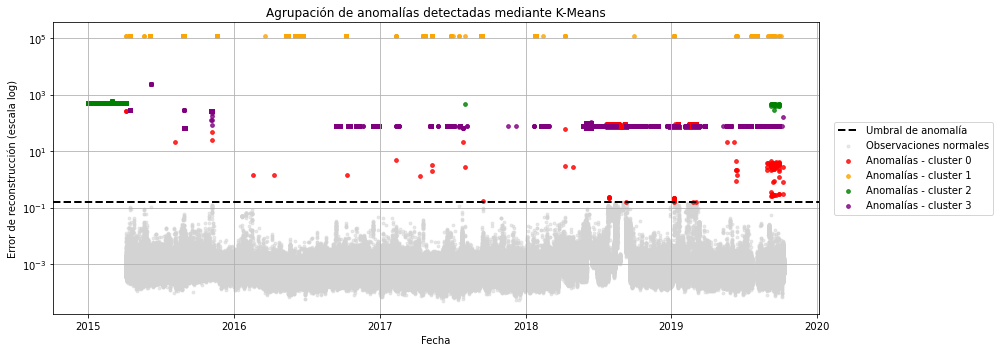

In [203]:
# Visualizar los clusters en el tiempo
plt.figure(figsize=(14, 5))

# Máscara de observaciones normales
normal_points = results_cluster_df["is_anomaly"] == False

# Observaciones normales en gris
plt.scatter(
    results_cluster_df.loc[normal_points, "datetime"],
    results_cluster_df.loc[normal_points, "reconstruction_error"],
    s=8,
    color="lightgray",
    alpha=0.5,
    label="Observaciones normales"
)

# Colores para los clusters de anomalías
cluster_colors = {
    0: "red",
    1: "orange",
    2: "green",
    3: "purple",
    4: "blue"
}

# Anomalías coloreadas por cluster
for cluster_id in sorted(anomalies_df["error_cluster"].unique()):
    cluster_data = anomalies_df[anomalies_df["error_cluster"] == cluster_id]

    plt.scatter(
        cluster_data["datetime"],
        cluster_data["reconstruction_error"],
        s=14,
        color=cluster_colors.get(cluster_id, None),
        alpha=0.8,
        label=f"Anomalías - cluster {cluster_id}"
    )

# Umbral de anomalía
plt.axhline(
    y=threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Umbral de anomalía"
)

plt.yscale("log")

plt.xlabel("Fecha")
plt.ylabel("Error de reconstrucción (escala log)")
plt.title("Agrupación de anomalías detectadas mediante K-Means")
plt.legend()
plt.grid(True, which="both")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)

plt.tight_layout()
plt.show()

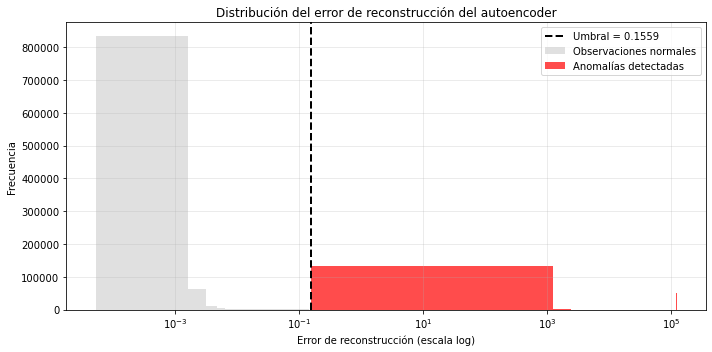

In [204]:
def plot_reconstruction_error_distribution(
    results_cluster_df,
    threshold,
    error_col="reconstruction_error",
    anomaly_col="is_anomaly"
):
    data = results_cluster_df[[error_col, anomaly_col]].dropna().copy()

    normal = data[data[anomaly_col] == False]
    anom = data[data[anomaly_col] == True]

    plt.figure(figsize=(10, 5))

    plt.hist(
        normal[error_col],
        bins=100,
        alpha=0.7,
        color="lightgray",
        label="Observaciones normales"
    )

    plt.hist(
        anom[error_col],
        bins=100,
        alpha=0.7,
        color="red",
        label="Anomalías detectadas"
    )

    plt.axvline(
        threshold,
        color="black",
        linestyle="--",
        linewidth=2,
        label=f"Umbral = {threshold:.4f}"
    )

    plt.xscale("log")

    plt.xlabel("Error de reconstrucción (escala log)")
    plt.ylabel("Frecuencia")
    plt.title("Distribución del error de reconstrucción del autoencoder")
    plt.legend()
    plt.grid(True, alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()
    
plot_reconstruction_error_distribution(
    results_cluster_df,
    threshold=threshold
)

In [205]:
#Probar sobre val y test
X_all_val_full = np.vstack([
    #X_train_full,
    X_val_full,
    X_test_full
])

# Concatenamos los dataframes en el mismo orden
all_val_df = pd.concat(
    [val_df_full, test_df_full],
    axis=0
).reset_index(drop=True)

# Reconstrucción del autoencoder
X_all_val_pred = autoencoder.predict(X_all_val_full, verbose=0)

# Error cuadrático por variable
error_val = X_all_val_full - X_all_val_pred
abs_error_val = np.abs(error_val)
delta = 1.0

errors_by_var_val = np.where(
    abs_error_val <= delta,
    0.5 * error_val**2,
    delta * (abs_error_val - 0.5 * delta)
)

error_cols_val = [f"error_{col}" for col in numeric_features]

errors_by_var_df_val = pd.DataFrame(
    errors_by_var_val,
    columns=error_cols_val
)

# Dataset completo con errores por variable
results_cluster_val_df = pd.concat(
    [all_val_df, errors_by_var_df_val],
    axis=1
)

# Orden temporal
results_cluster_val_df = results_cluster_val_df.sort_values("datetime").reset_index(drop=True)

# Seleccionar solo las anomalías
anomalies_val_df = results_cluster_val_df[
    results_cluster_val_df["is_anomaly"] == True
].copy()

print("Número de anomalías:", len(anomalies_val_df))

Número de anomalías: 511040


In [206]:
# Usar exactamente las mismas columnas de error que en el entrenamiento del K-Means
X_anomalies_val_errors = anomalies_val_df[error_cols].copy()

# Misma transformación logarítmica usada antes
X_anomalies_val_errors = np.log1p(X_anomalies_val_errors)

# Usar el scaler YA ENTRENADO
X_anomalies_val_errors_scaled = scaler_kmeans.transform(
    X_anomalies_val_errors
)

# Usar el K-Means YA ENTRENADO
anomalies_val_df["error_cluster"] = kmeans.predict(
    X_anomalies_val_errors_scaled
)

# Inicializar columna de cluster
results_cluster_val_df["error_cluster"] = np.nan

# Asignar cluster solo a las anomalías
results_cluster_val_df.loc[
    anomalies_val_df.index,
    "error_cluster"
] = anomalies_val_df["error_cluster"]

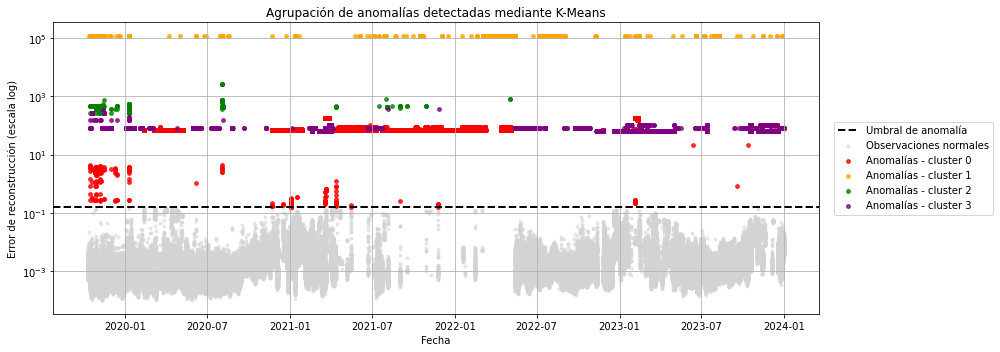

In [207]:
plt.figure(figsize=(14, 5))

# Máscara de observaciones normales
normal_points = results_cluster_val_df["is_anomaly"] == False

# Observaciones normales en gris
plt.scatter(
    results_cluster_val_df.loc[normal_points, "datetime"],
    results_cluster_val_df.loc[normal_points, "reconstruction_error"],
    s=8,
    color="lightgray",
    alpha=0.5,
    label="Observaciones normales"
)

# Colores para los clusters de anomalías
cluster_colors = {
    0: "red",
    1: "orange",
    2: "green",
    3: "purple",
    4: "blue"
}

# Anomalías coloreadas por cluster
for cluster_id in sorted(anomalies_val_df["error_cluster"].unique()):
    cluster_data = anomalies_val_df[anomalies_val_df["error_cluster"] == cluster_id]

    plt.scatter(
        cluster_data["datetime"],
        cluster_data["reconstruction_error"],
        s=14,
        color=cluster_colors.get(cluster_id, None),
        alpha=0.8,
        label=f"Anomalías - cluster {cluster_id}"
    )

# Umbral de anomalía
plt.axhline(
    y=threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Umbral de anomalía"
)

plt.yscale("log")

plt.xlabel("Fecha")
plt.ylabel("Error de reconstrucción (escala log)")
plt.title("Agrupación de anomalías detectadas mediante K-Means")
plt.legend()
plt.grid(True, which="both")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)

plt.tight_layout()
plt.show()

In [208]:
def plot_irradiance_power_clusters(
    results_cluster_df,
    col,
    col2,
    anomaly_col="is_anomaly",
    cluster_col="error_cluster",
    xlim=None
):
    data = results_cluster_df[
        [col, col2, anomaly_col, cluster_col]
    ].dropna(subset=[col, col2, anomaly_col]).copy()

    plt.figure(figsize=(9, 6))

    # Observaciones normales
    normal = data[data[anomaly_col] == False]

    plt.scatter(
        normal[col],
        normal[col2],
        s=3,
        alpha=0.15,
        color="lightgray",
        label="Observaciones normales"
    )

    # Colores para clusters
    cluster_colors = {
        0: "red",
        1: "orange",
        2: "green",
        3: "purple",
        4: "blue"
    }

    cluster_values = (
        data.loc[data[anomaly_col] == True, cluster_col]
        .dropna()
        .unique()
    )

    for cluster_id in sorted(cluster_values):
        cluster_id_int = int(cluster_id)

        cluster_data = data[
            (data[anomaly_col] == True) &
            (data[cluster_col] == cluster_id)
        ]

        plt.scatter(
            cluster_data[col],
            cluster_data[col2],
            s=18,
            marker="x",
            color=cluster_colors.get(cluster_id_int, None),
            alpha=0.85,
            label=f"Anomalías - cluster {cluster_id_int}"
        )

    # Escalas logarítmicas simétricas
    plt.xscale("symlog", linthresh=1)
    plt.yscale("symlog", linthresh=1)

    # Limitar eje X
    if xlim is not None:
        plt.xlim(xlim)

    plt.xlabel(f"{col}")
    plt.ylabel(f"{col2}")
    plt.title("Relación entre variables")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)

    plt.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0
    )    
    
    plt.tight_layout()
    plt.show()

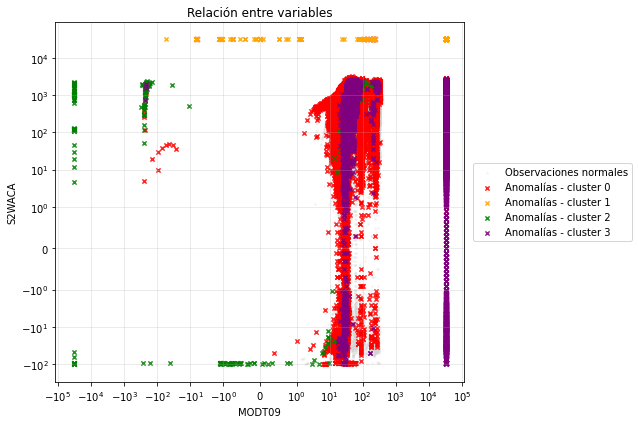

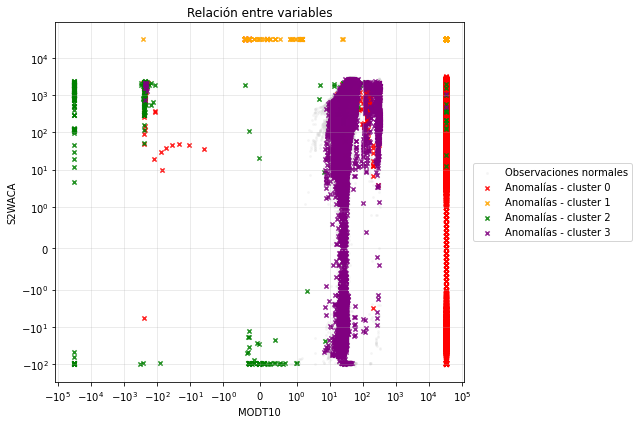

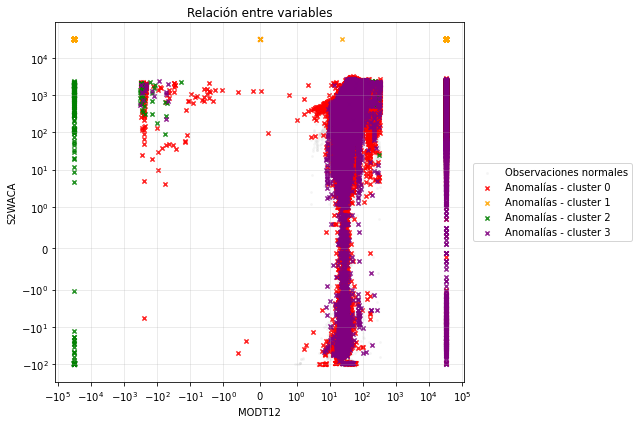

In [209]:
plot_irradiance_power_clusters(
    results_cluster_val_df,
    col="MODT09",  
    col2="S2WACA"
)    

plot_irradiance_power_clusters(
    results_cluster_val_df,
    col="MODT10",  
    col2="S2WACA"
)    

plot_irradiance_power_clusters(
    results_cluster_val_df,
    col="MODT12",  
    col2="S2WACA"
)    

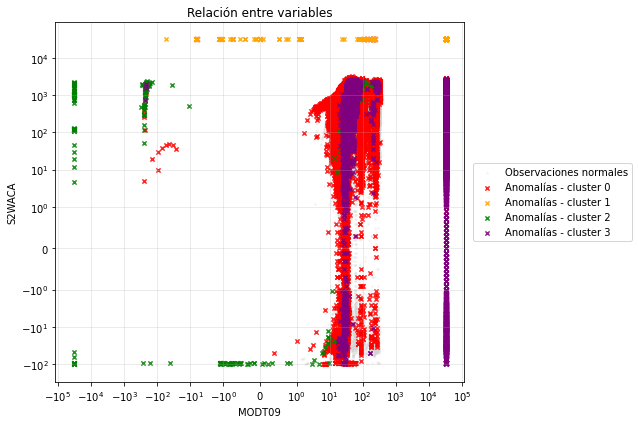

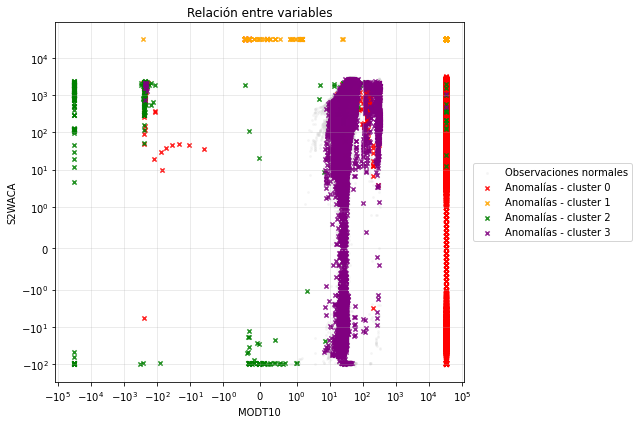

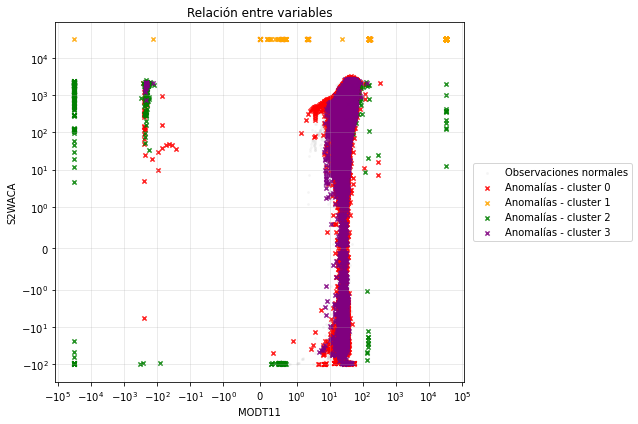

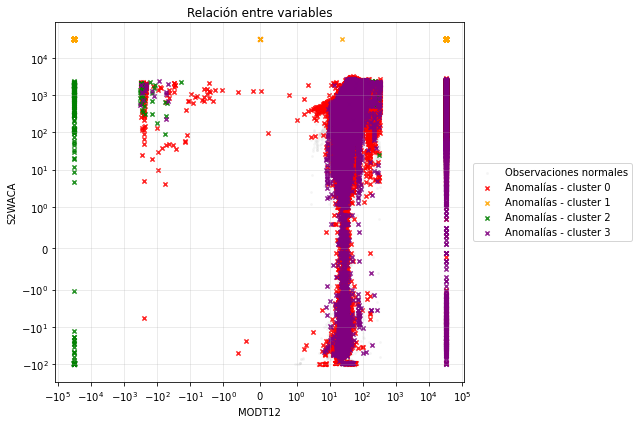

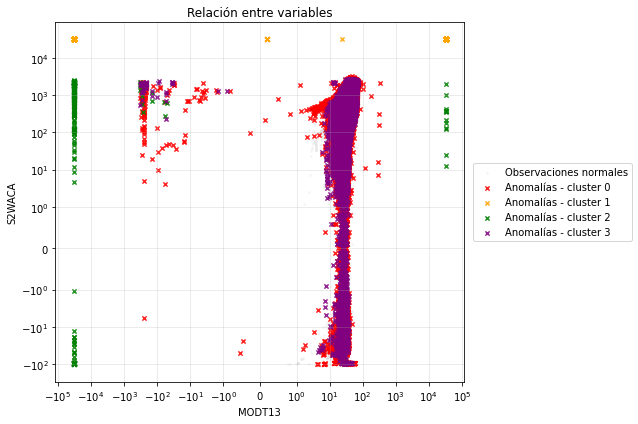

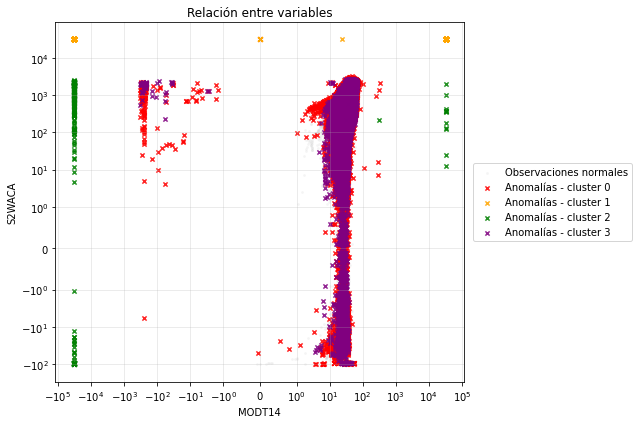

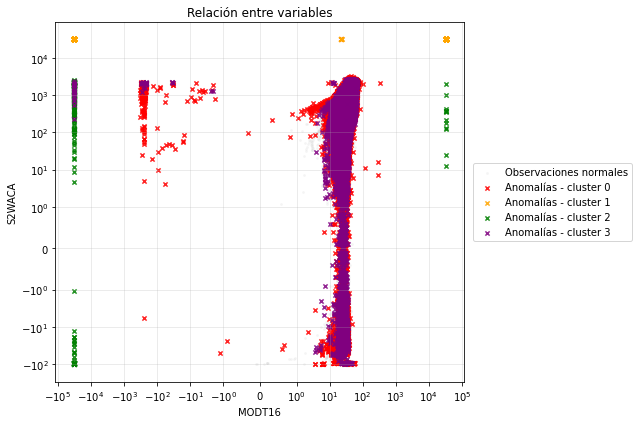

In [210]:
for feature in MODULE_TEMP_COLUMNS:
    plot_irradiance_power_clusters(
        results_cluster_val_df,
        col=feature,  
        col2="S2WACA"
    )    

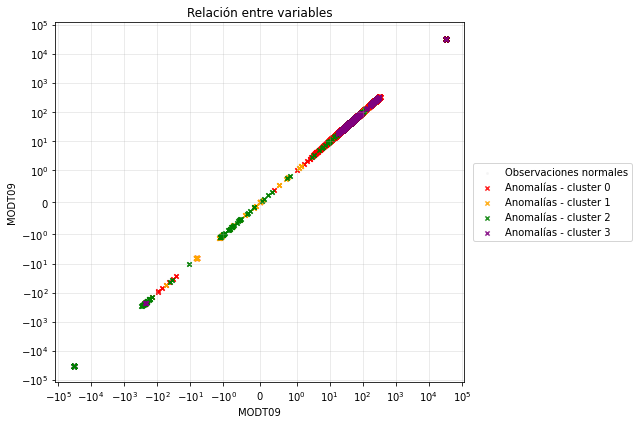

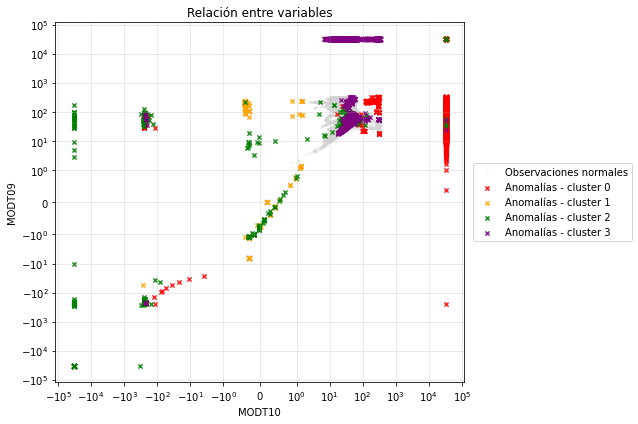

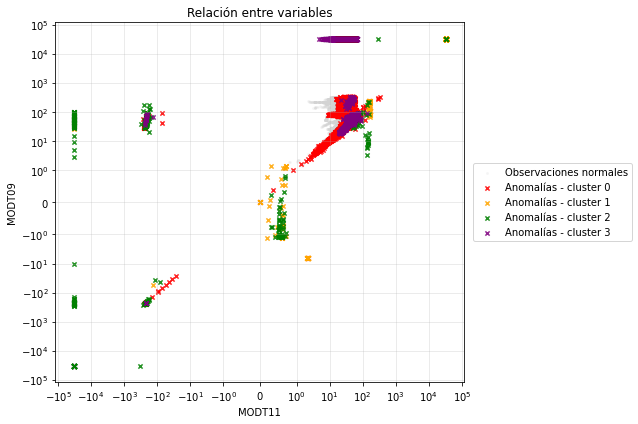

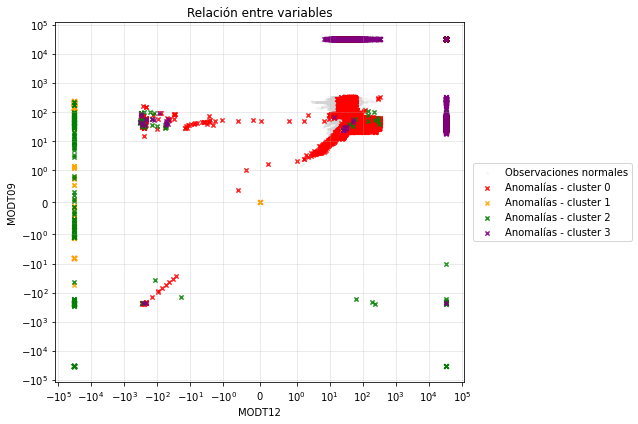

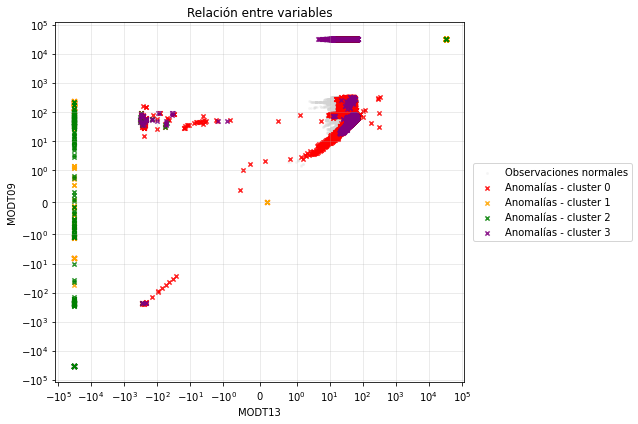

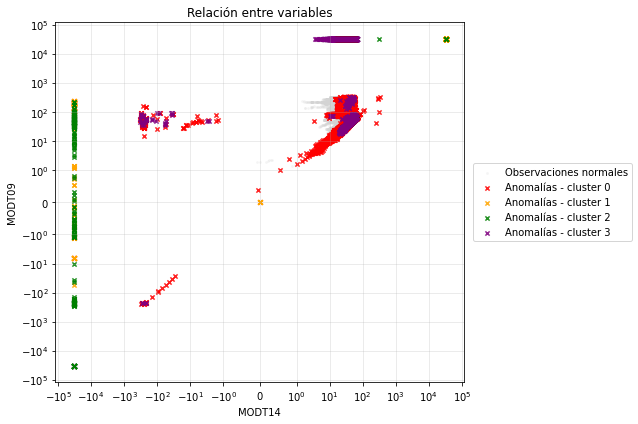

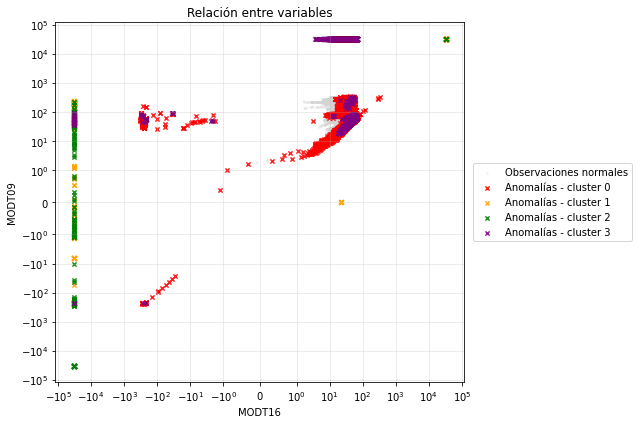

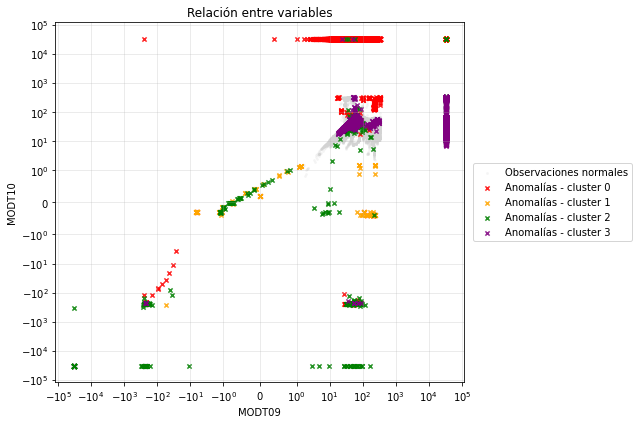

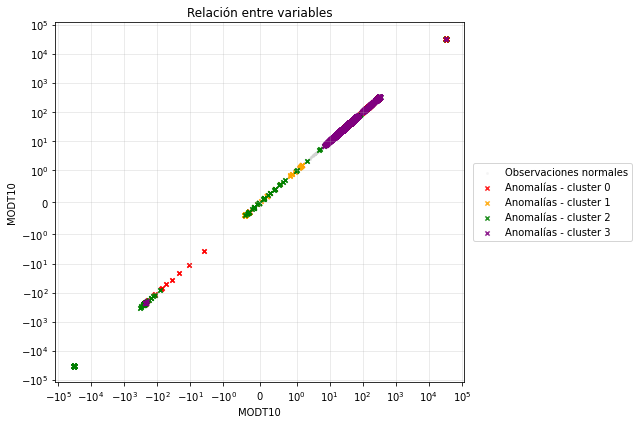

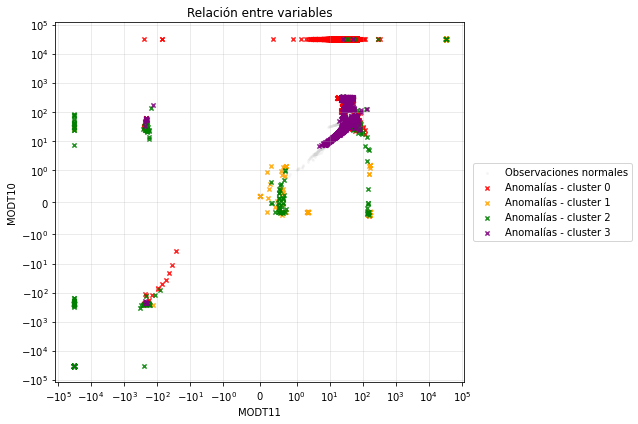

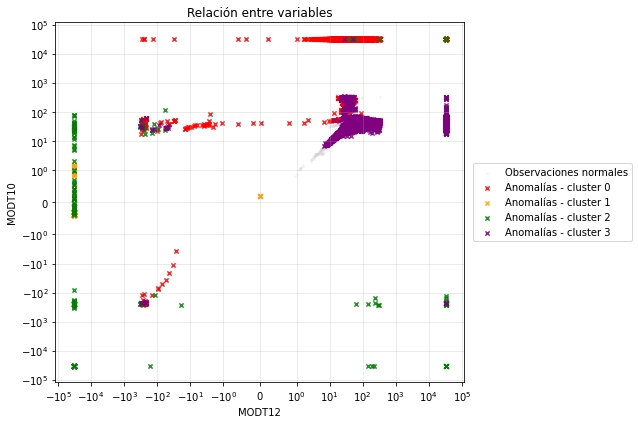

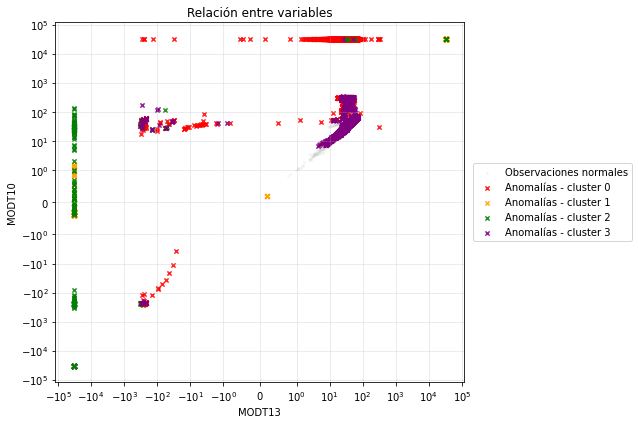

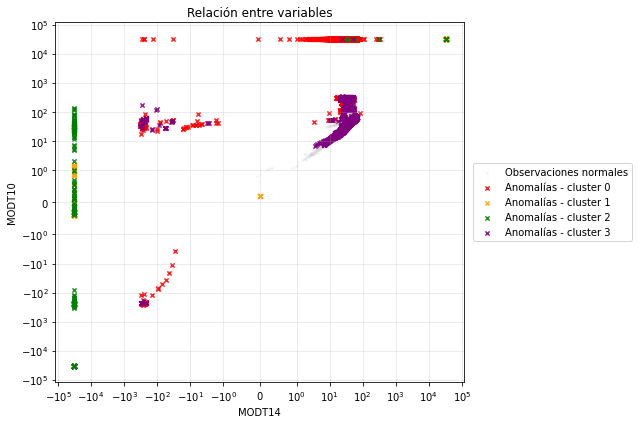

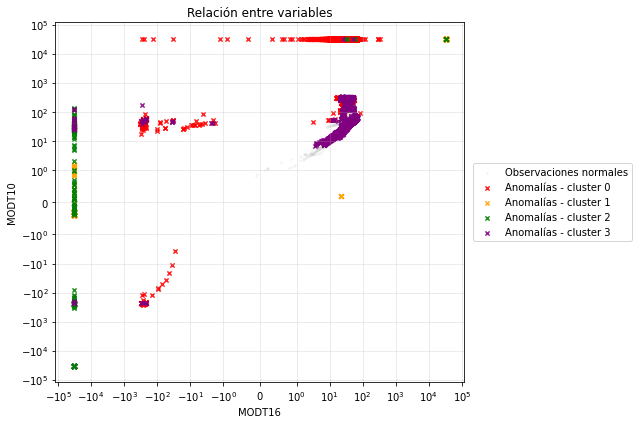

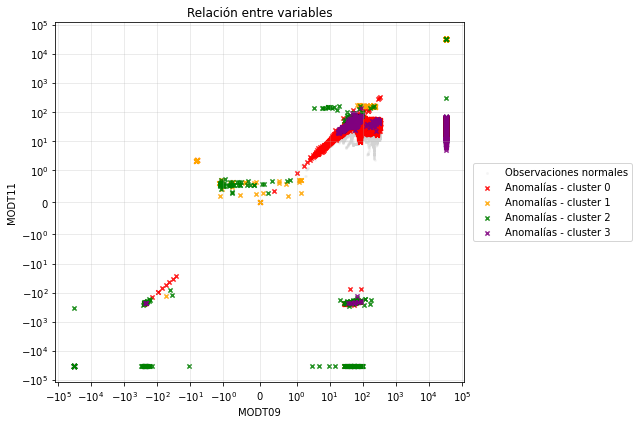

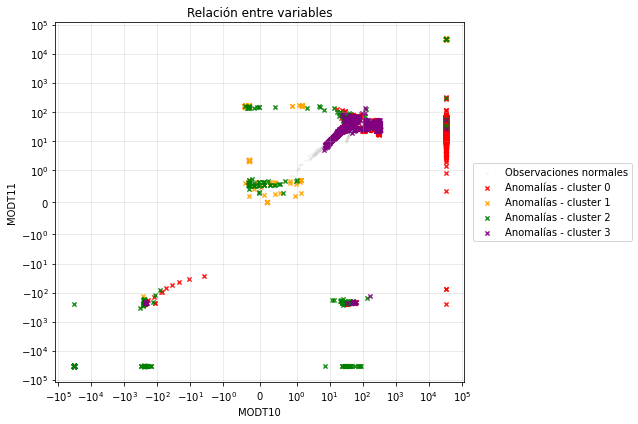

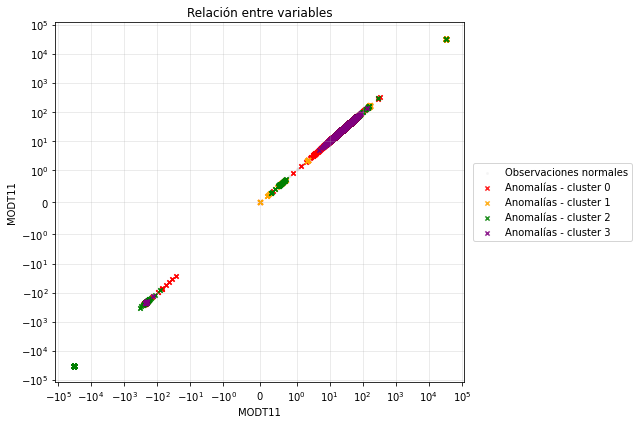

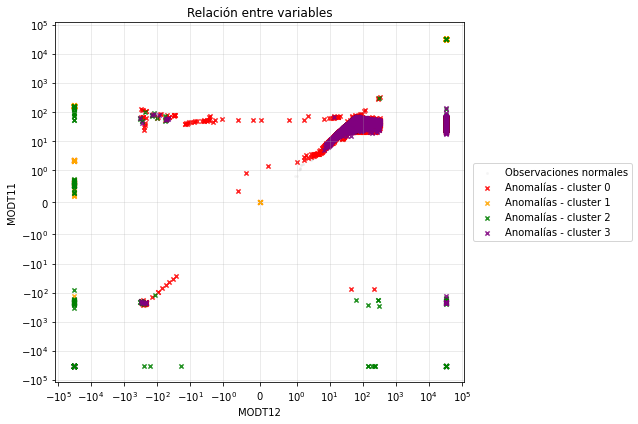

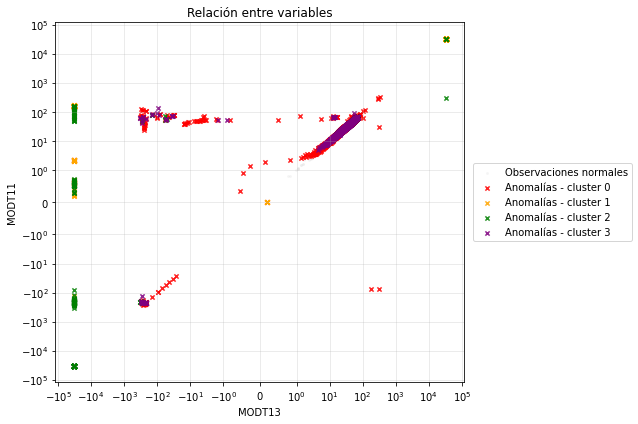

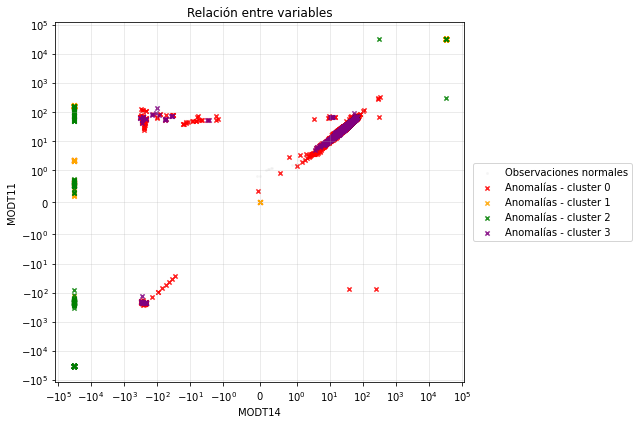

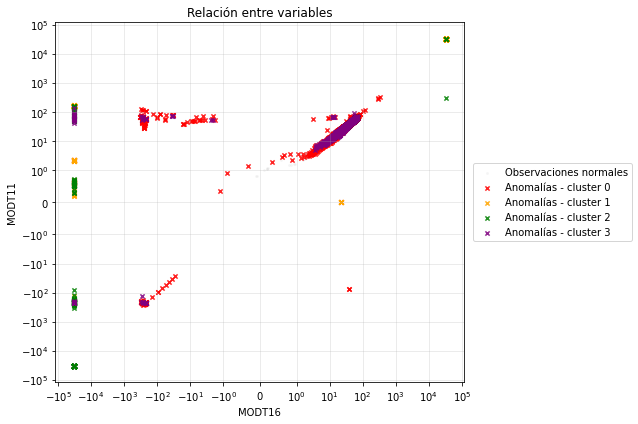

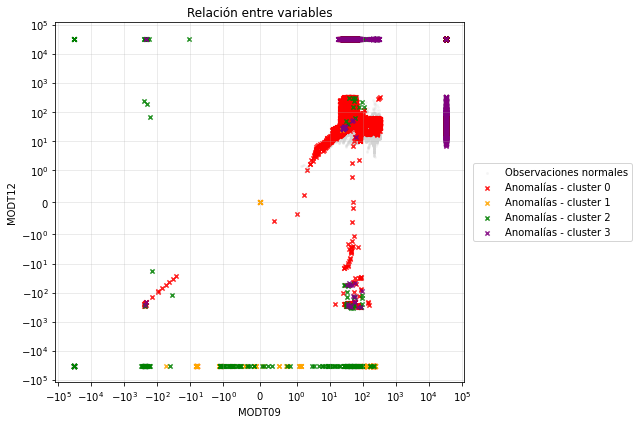

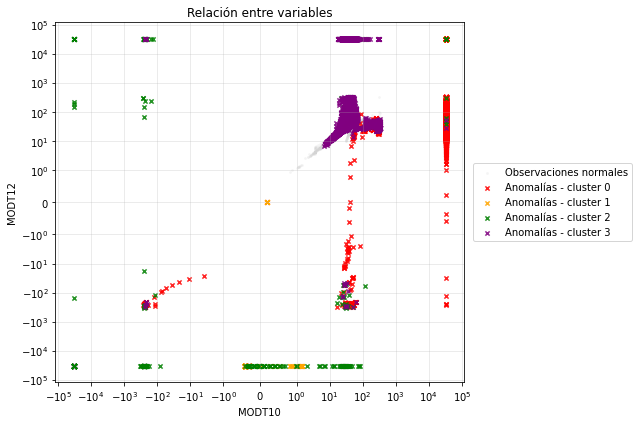

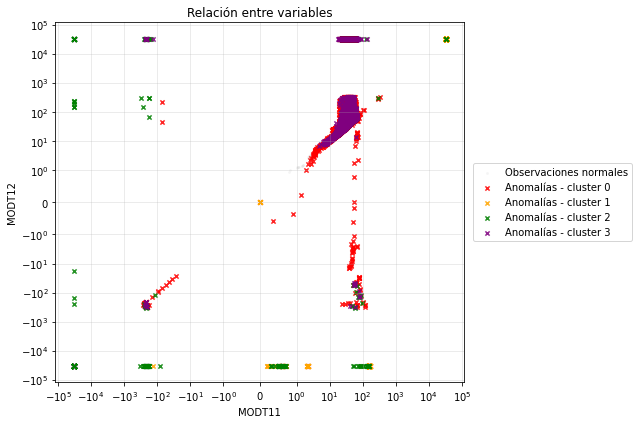

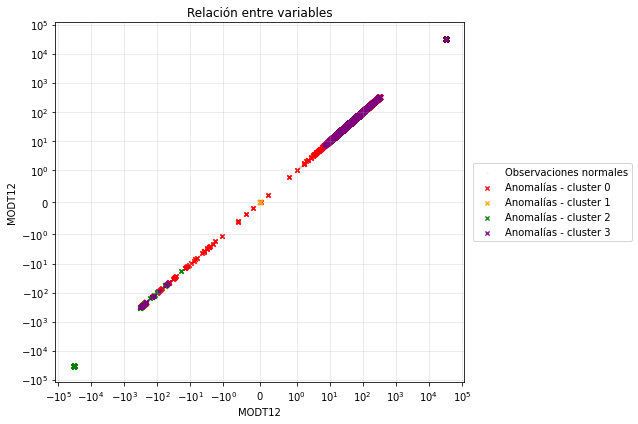

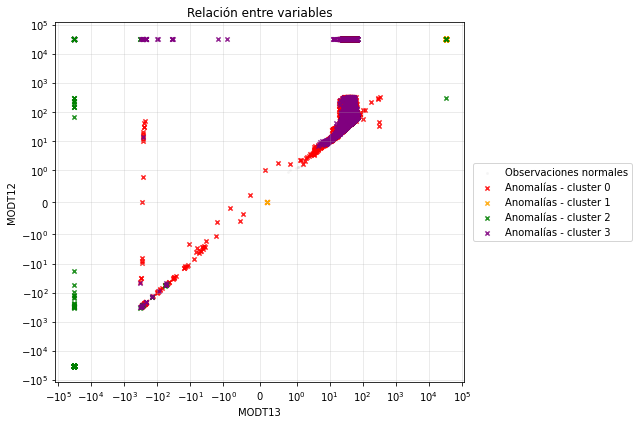

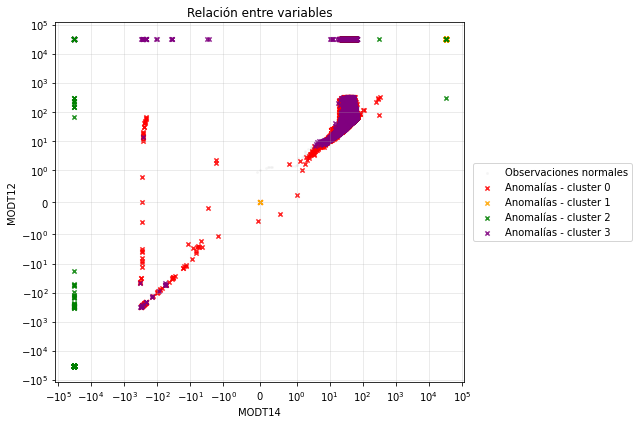

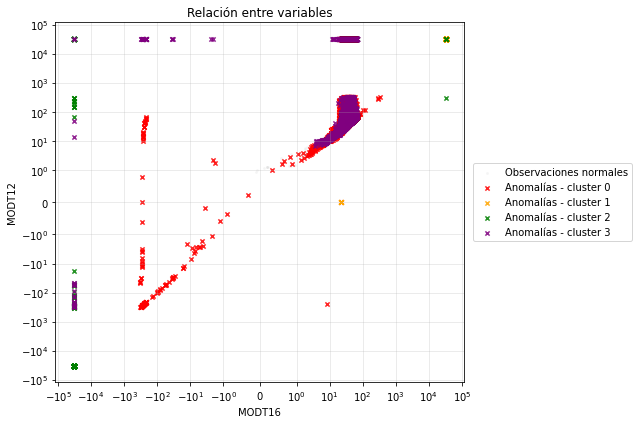

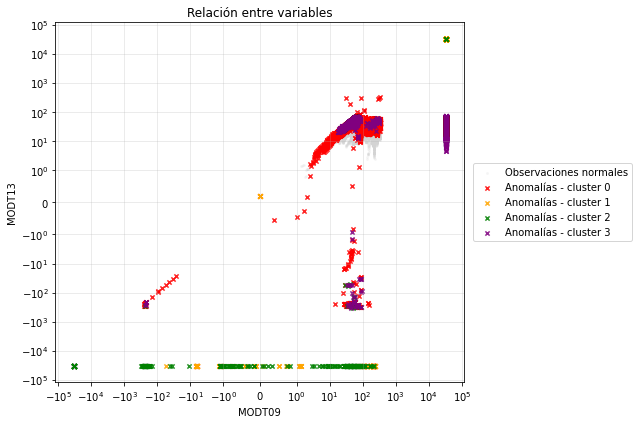

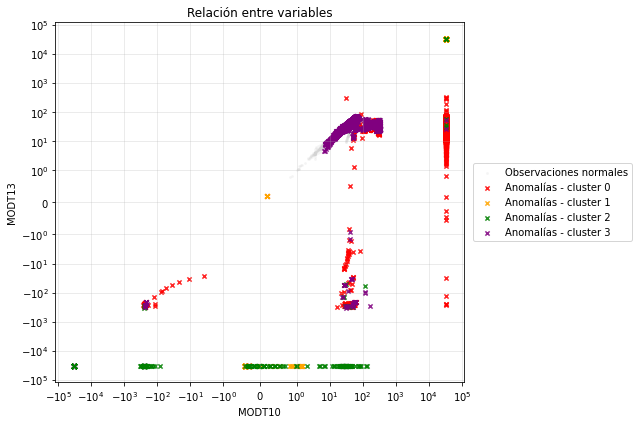

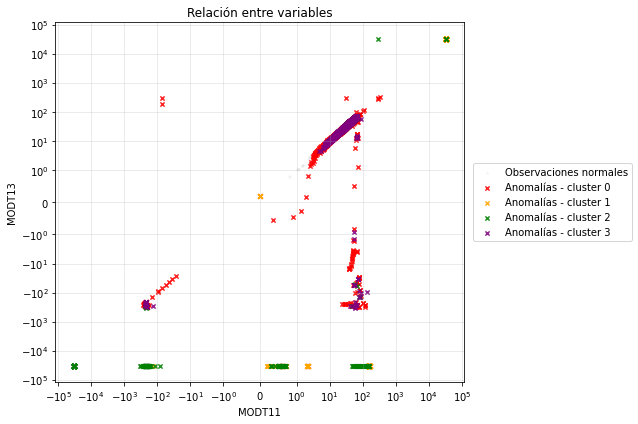

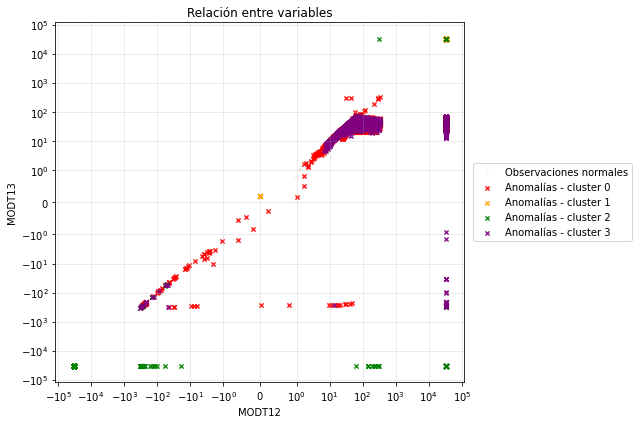

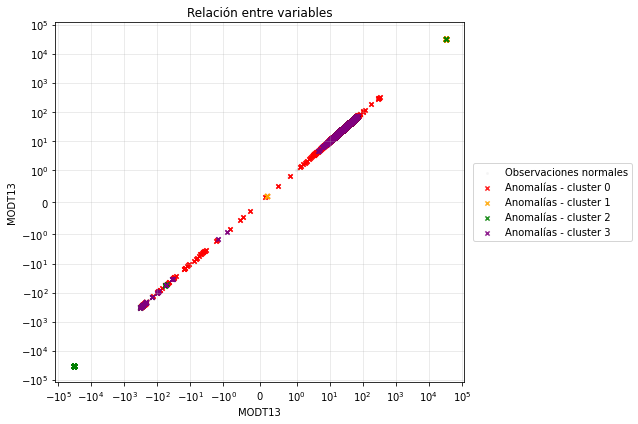

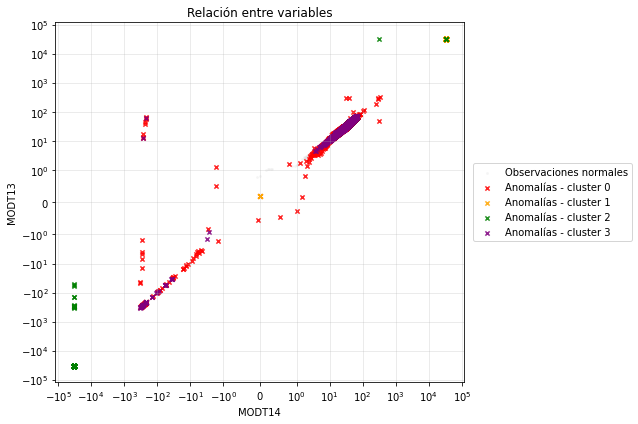

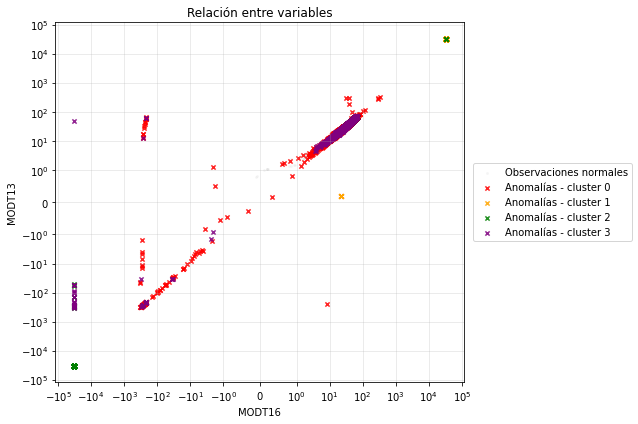

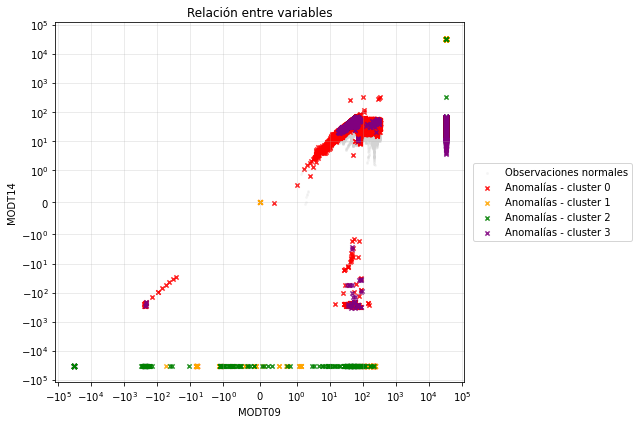

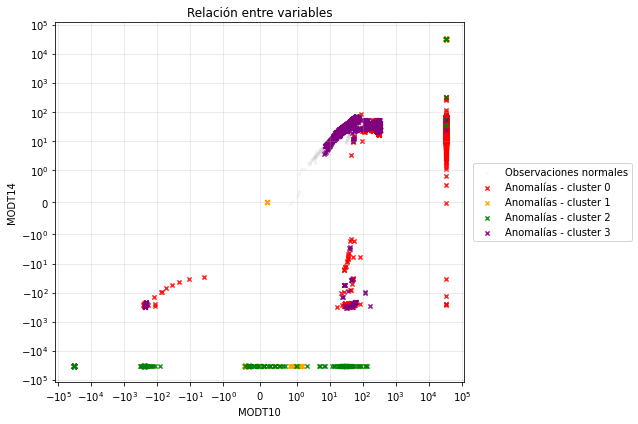

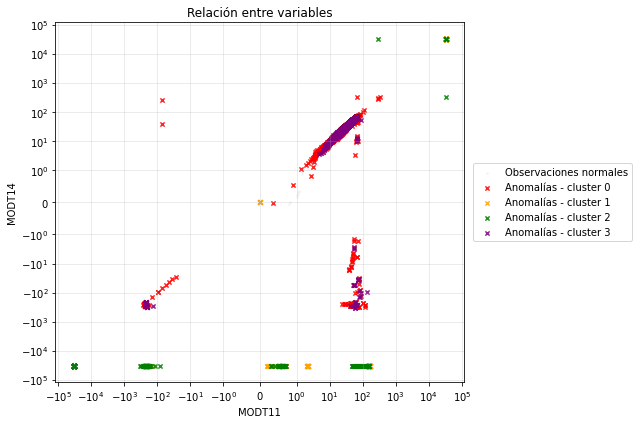

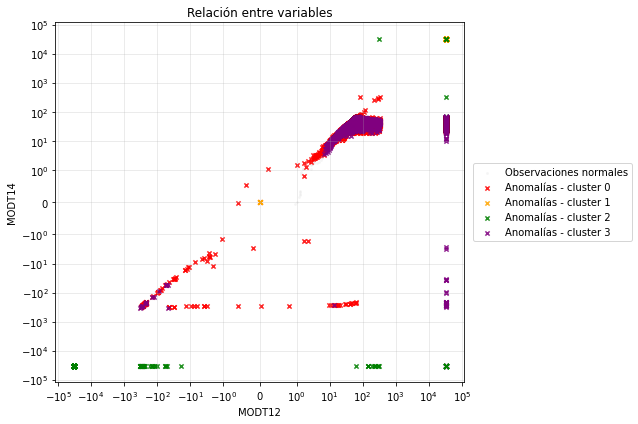

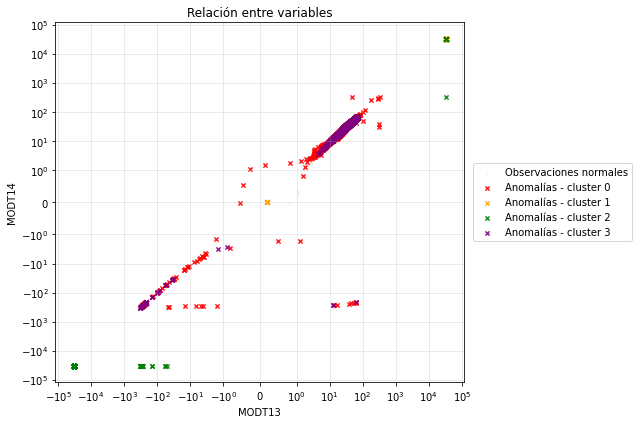

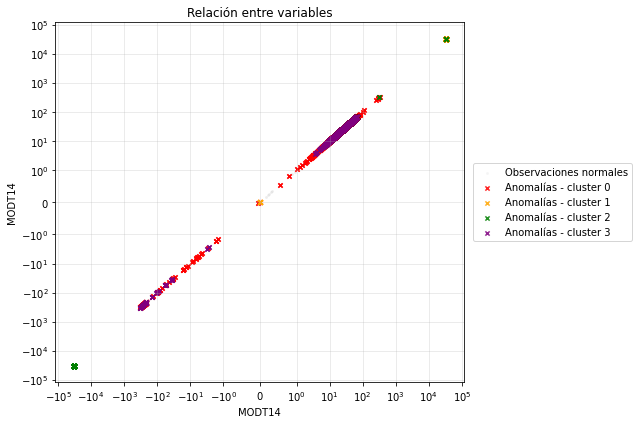

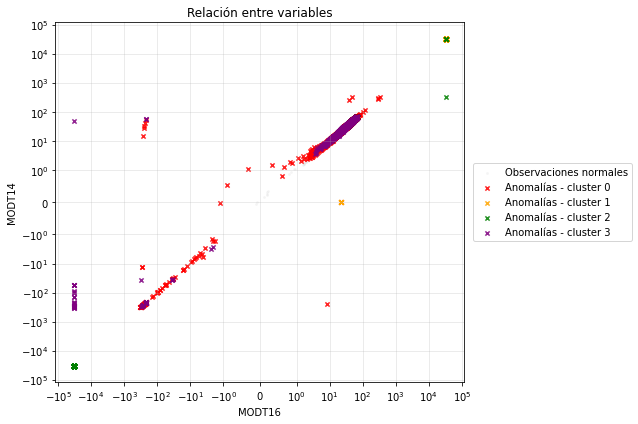

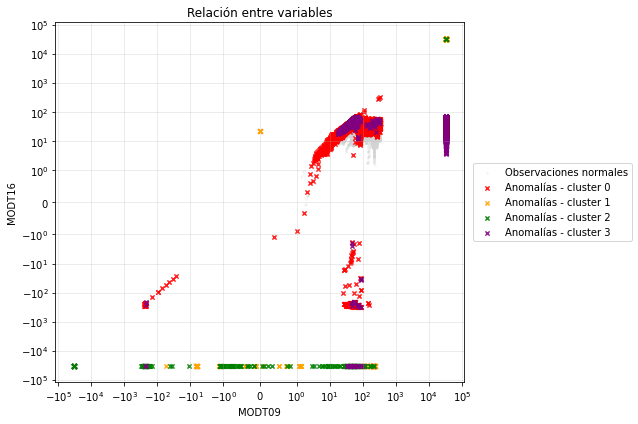

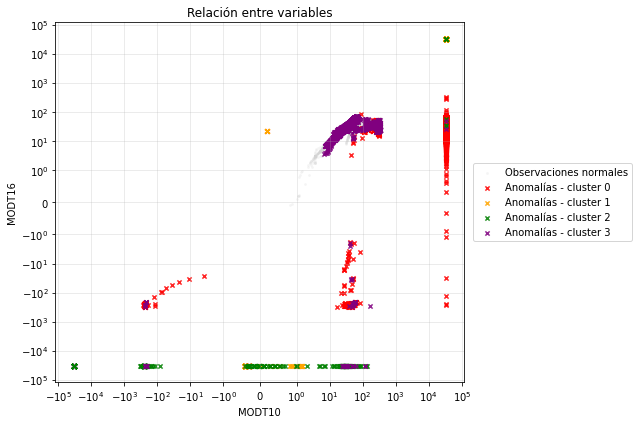

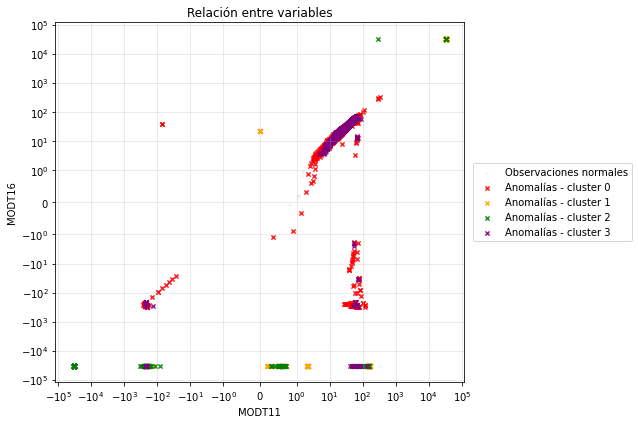

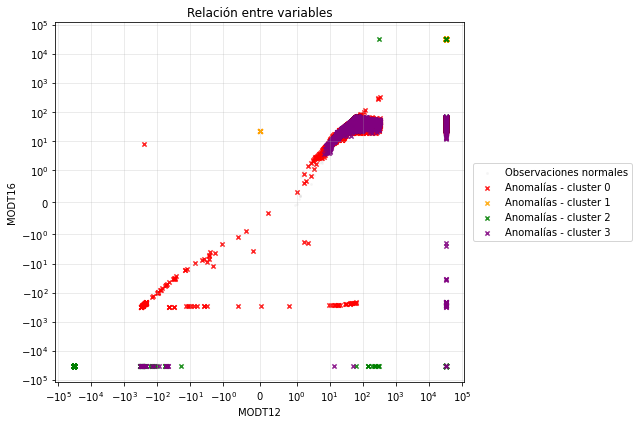

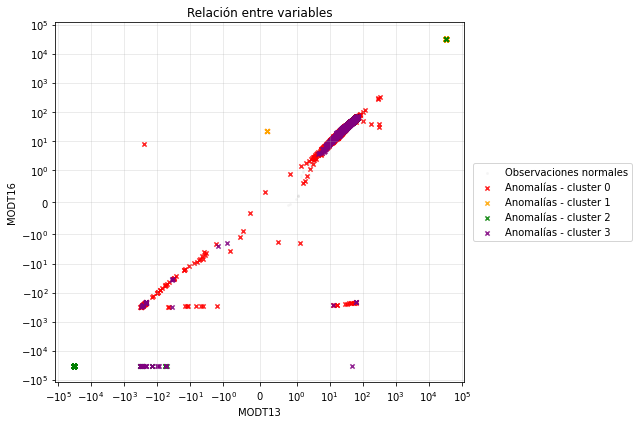

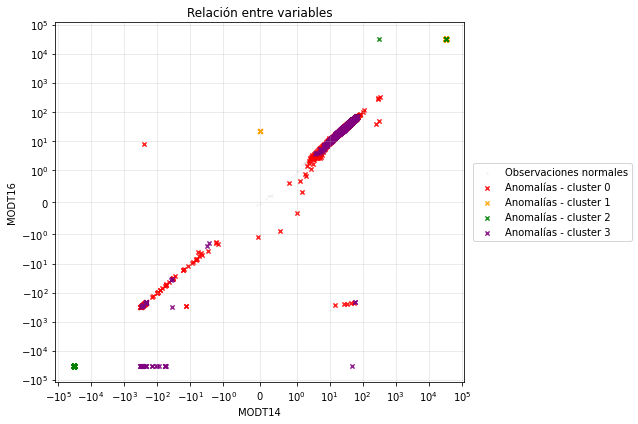

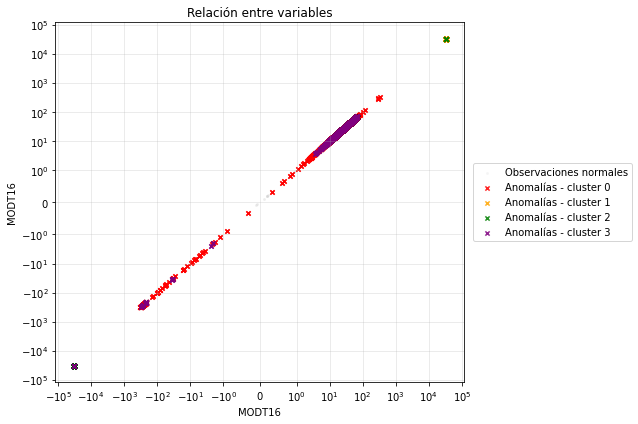

In [211]:
for feature_y in MODULE_TEMP_COLUMNS:
    for feature_x in MODULE_TEMP_COLUMNS:
        plot_irradiance_power_clusters(
            results_cluster_val_df,
            col=feature_x,  
            col2=feature_y
        )    

In [212]:
import matplotlib.pyplot as plt

def plot_abs_error_vs_power_autoencoder(
    df_result,
    power_col="S2WACA",
    error_power_col="error_S2WACA",
    anomaly_col="is_anomaly",
    cluster_col=None
):
    data_cols = [power_col, error_power_col, anomaly_col]

    if cluster_col is not None:
        data_cols.append(cluster_col)

    data = df_result[
        data_cols
    ].dropna(subset=[power_col, error_power_col, anomaly_col]).copy()

    normal = data[data[anomaly_col] == False]
    anom = data[data[anomaly_col] == True]

    plt.figure(figsize=(10, 6))

    # Observaciones normales
    plt.scatter(
        normal[power_col],
        normal[error_power_col],
        s=3,
        alpha=0.15,
        color="lightgray",
        label="Observaciones normales"
    )

    # Anomalías sin clusters
    if cluster_col is None:
        plt.scatter(
            anom[power_col],
            anom[error_power_col],
            s=18,
            marker="x",
            color="red",
            label="Anomalías detectadas"
        )

    # Anomalías con clusters
    else:
        cluster_colors = {
            0: "red",
            1: "orange",
            2: "green",
            3: "purple"
        }

        cluster_values = anom[cluster_col].dropna().unique()

        for cluster_id in sorted(cluster_values):
            cluster_id_int = int(cluster_id)

            cluster_data = anom[anom[cluster_col] == cluster_id]

            plt.scatter(
                cluster_data[power_col],
                cluster_data[error_power_col],
                s=18,
                marker="x",
                color=cluster_colors.get(cluster_id_int, None),
                alpha=0.85,
                label=f"Anomalías - cluster {cluster_id_int}"
            )

    # Escala logarítmica para el error
    plt.xscale("symlog", linthresh=1e-4)
    plt.yscale("symlog", linthresh=1e-4)

    plt.xlabel(f"{power_col}")
    plt.ylabel(f"Error absoluto de reconstrucción - {power_col} (escala log)")
    plt.title(f"Error de reconstrucción frente a {power_col}")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

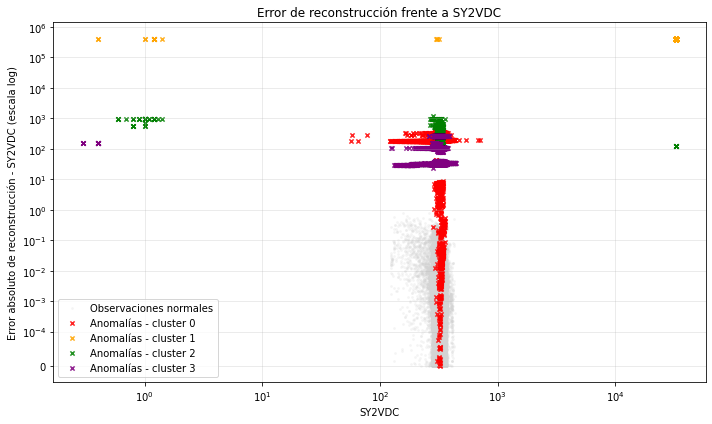

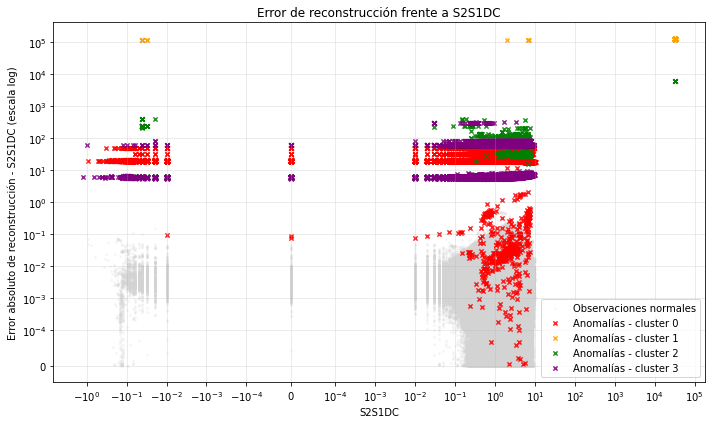

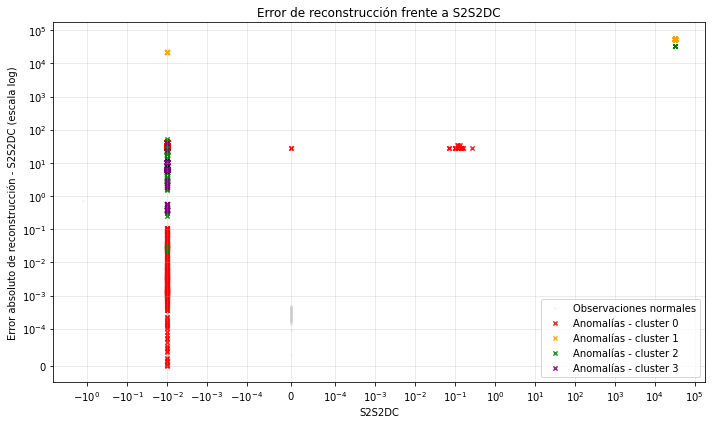

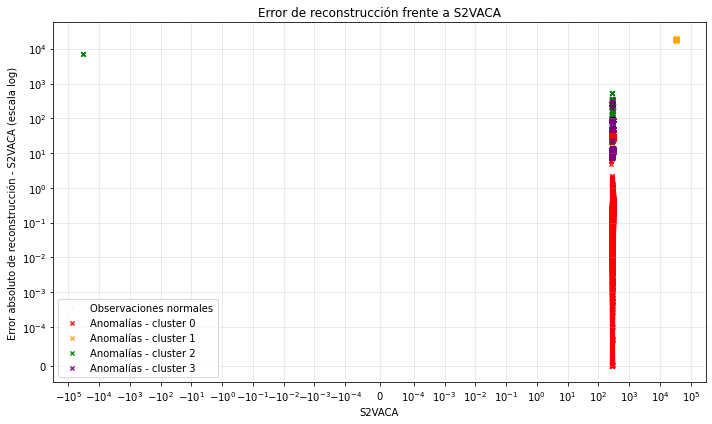

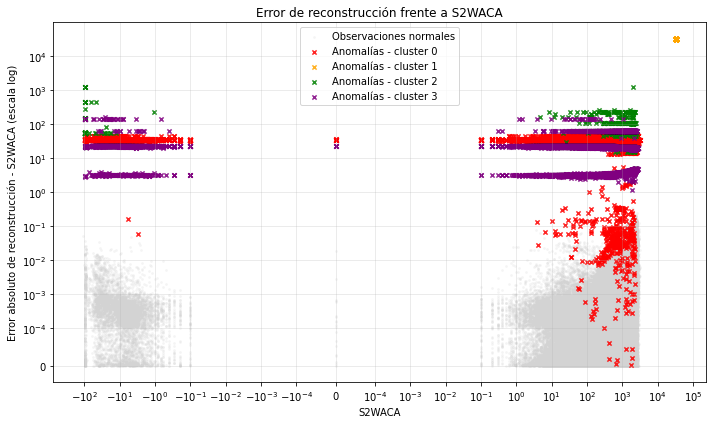

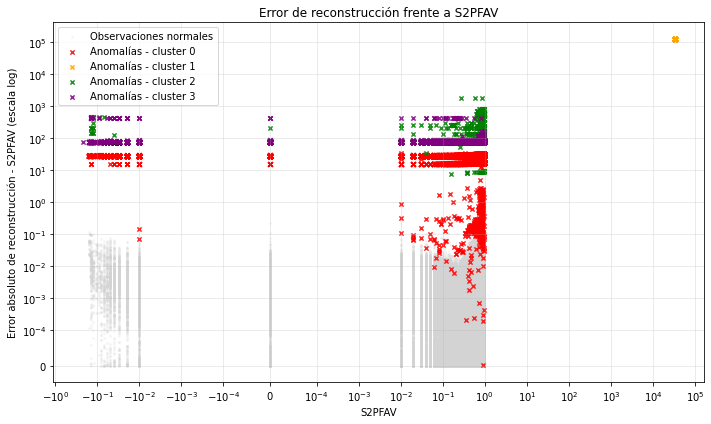

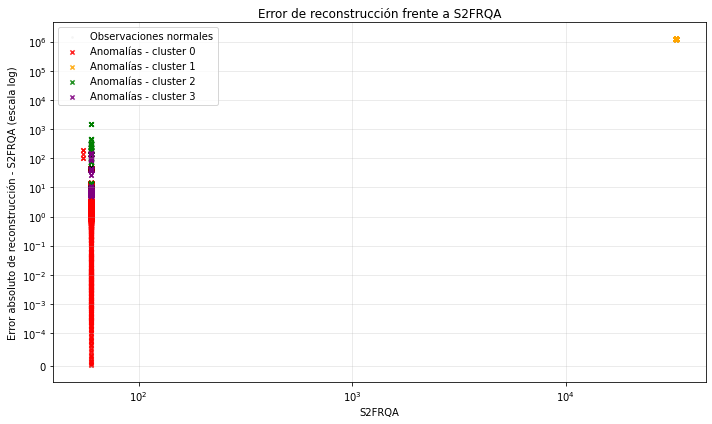

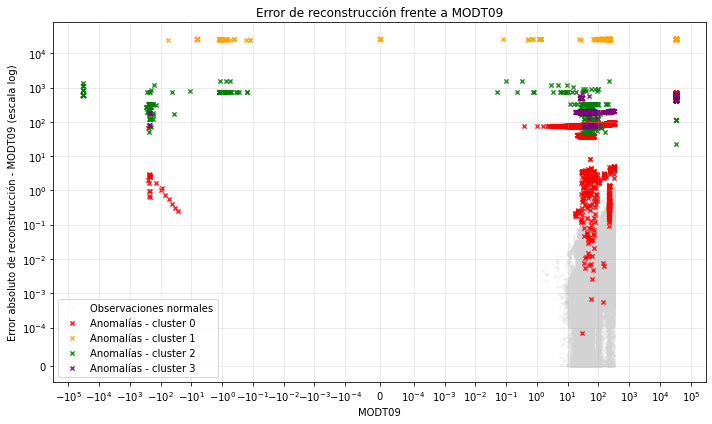

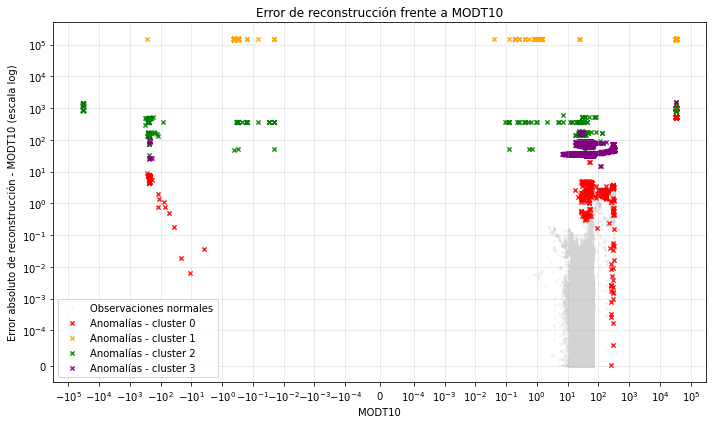

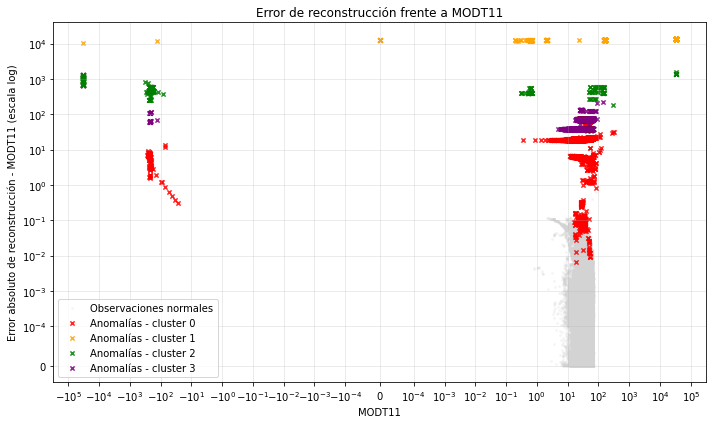

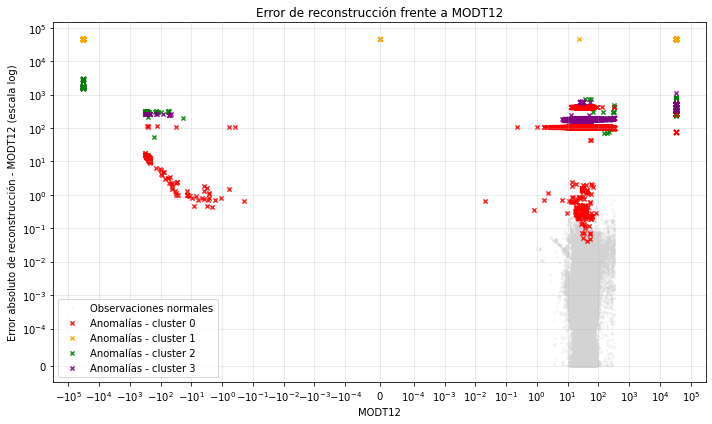

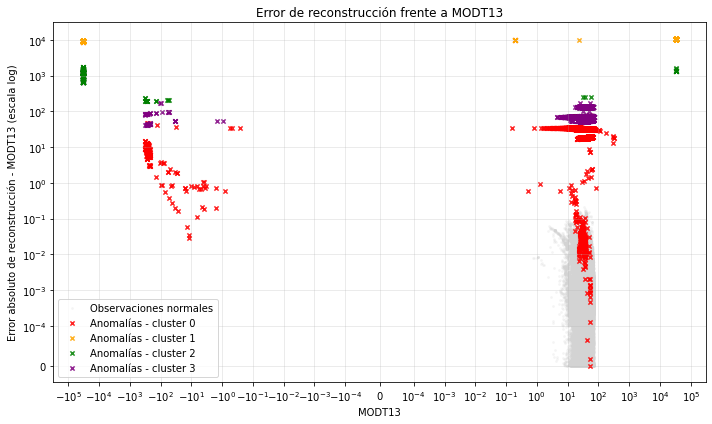

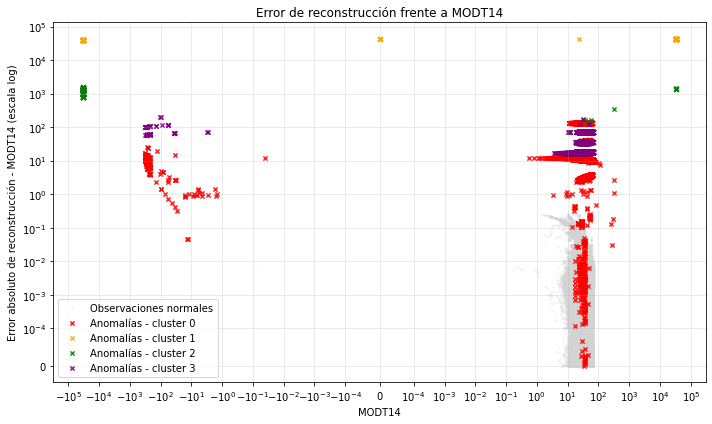

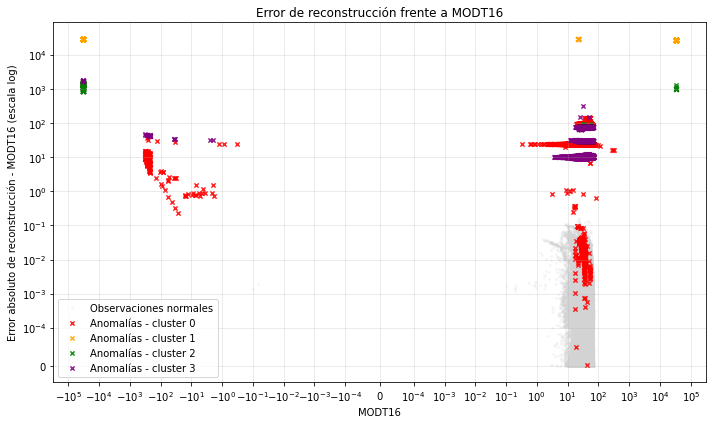

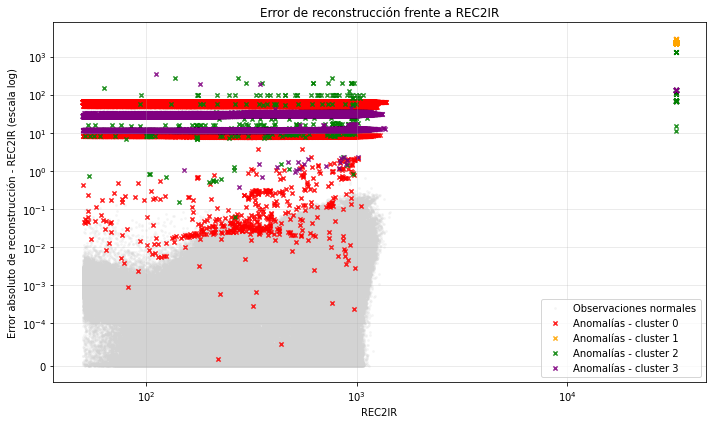

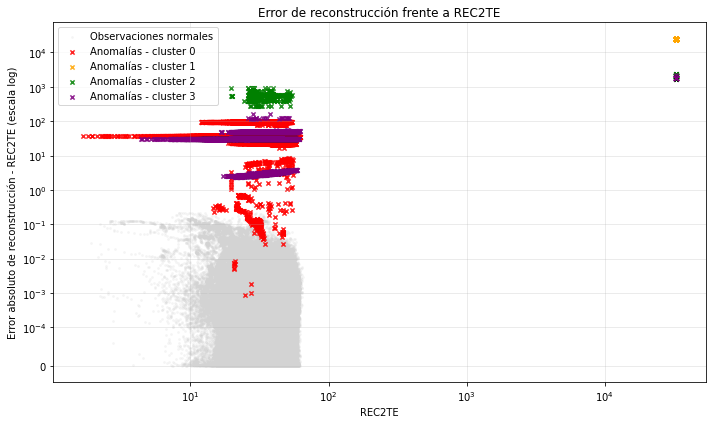

C:\Users\IIGO~1\AppData\Local\Temp/ipykernel_12988/2304136940.py:80: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\ProgramData\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


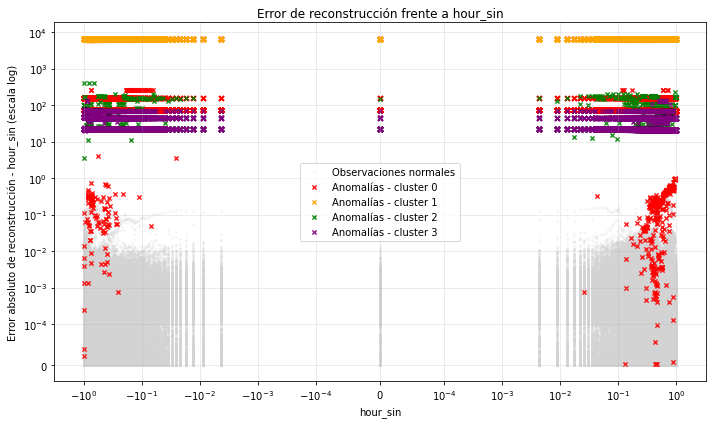

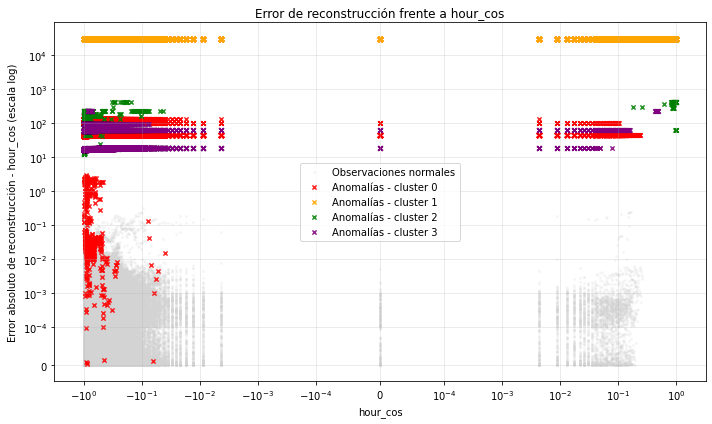

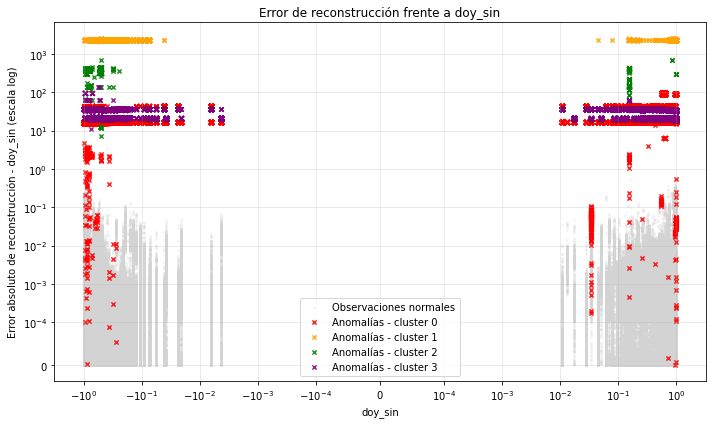

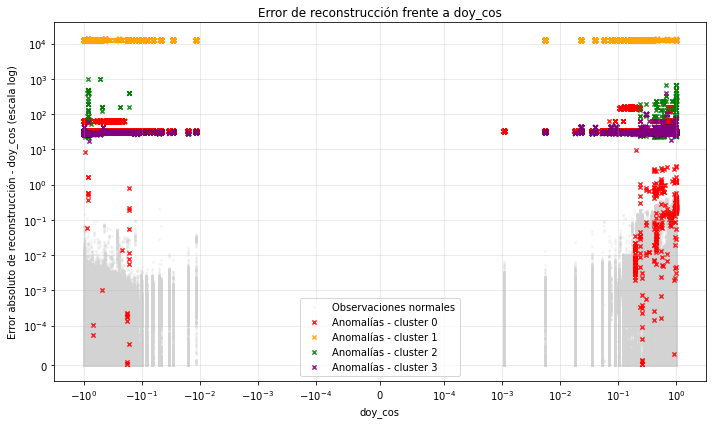

In [213]:
for feature in numeric_features:
    plot_abs_error_vs_power_autoencoder(
        results_cluster_val_df,
        power_col=feature,
        error_power_col="error_" + feature,
        anomaly_col="is_anomaly",
        cluster_col="error_cluster"
    )

In [214]:
results_cluster_val_df["module_temp_reconstruction_error"] = results_cluster_val_df[["error_" + col for col in MODULE_TEMP_COLUMNS]].mean(axis=1)

In [215]:
results_cluster_val_df["module_temp_mean"] = results_cluster_val_df[MODULE_TEMP_COLUMNS].mean(axis=1)

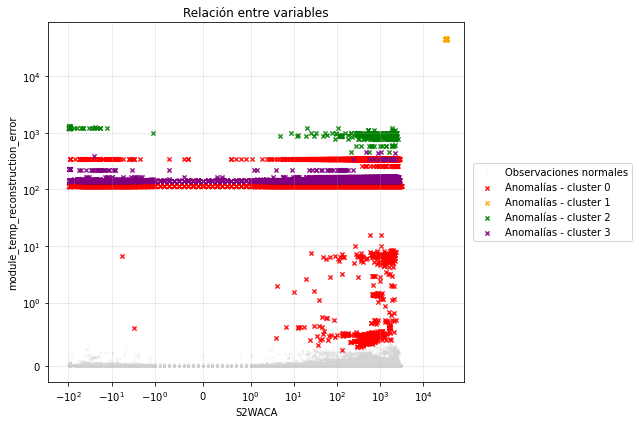

In [216]:
plot_irradiance_power_clusters(
    results_cluster_val_df,
    col='S2WACA',  
    col2="module_temp_reconstruction_error"
)    

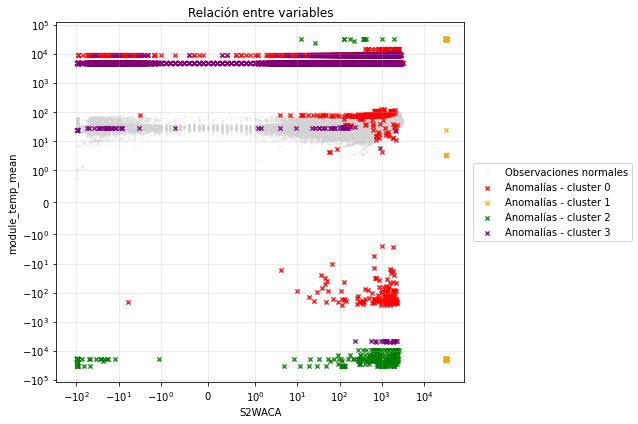

In [217]:
plot_irradiance_power_clusters(
    results_cluster_val_df,
    col='S2WACA',  
    col2="module_temp_mean"
)    

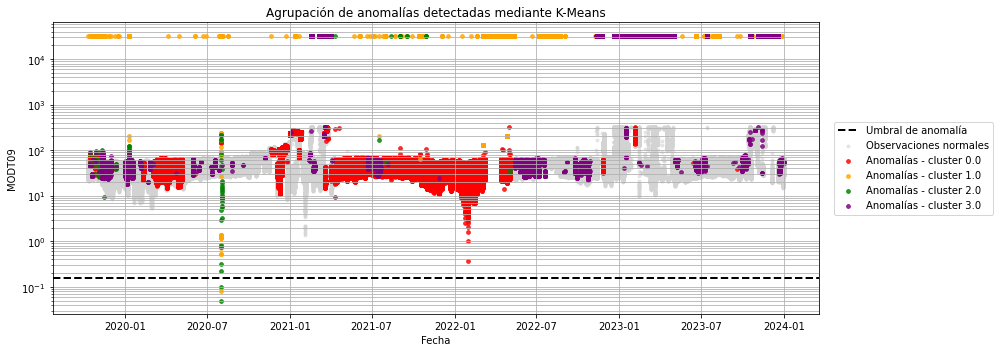

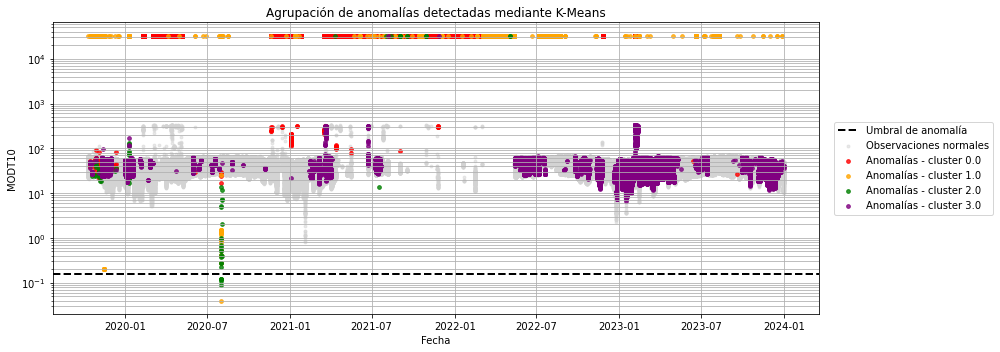

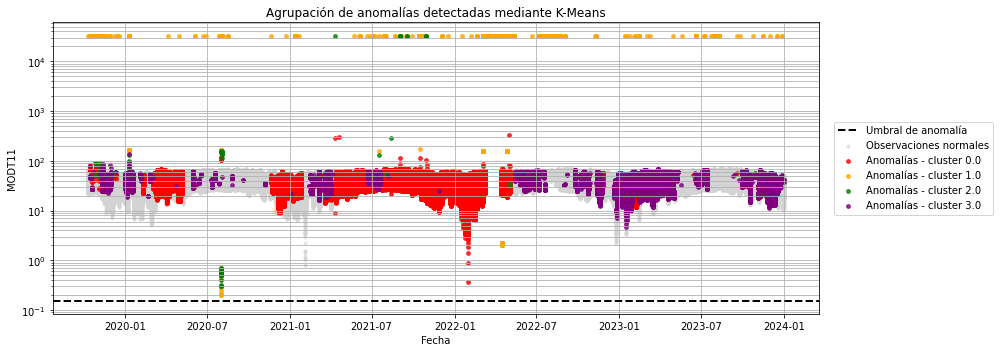

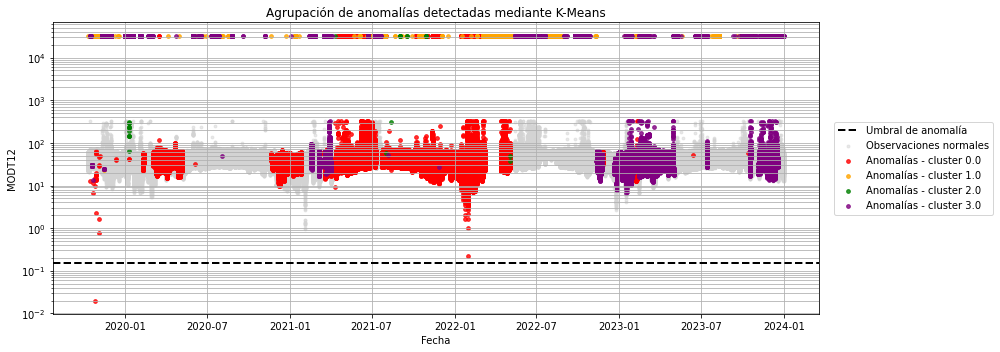

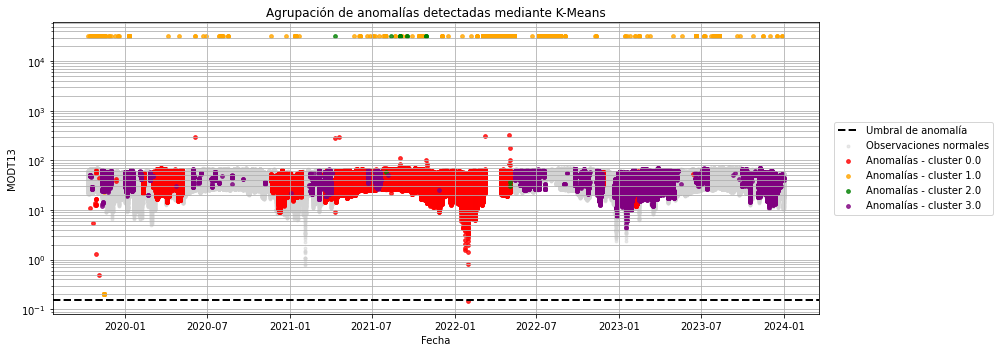

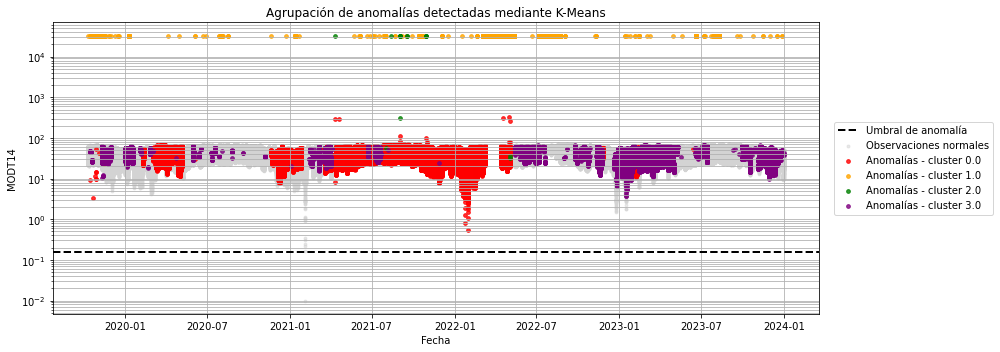

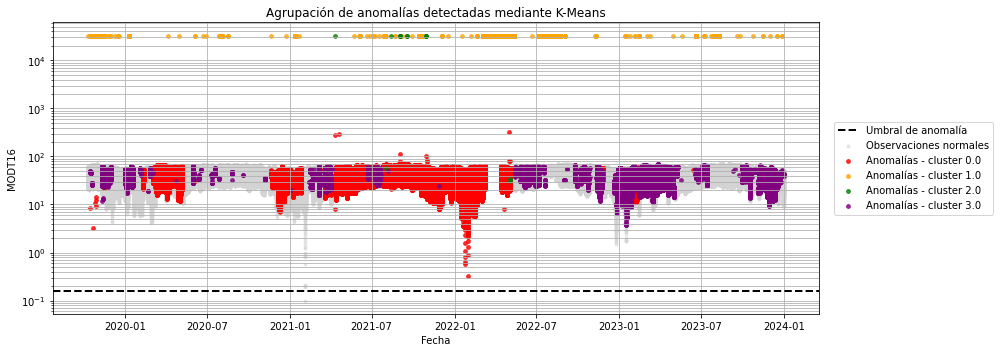

In [227]:
for var in MODULE_TEMP_COLUMNS:
    plt.figure(figsize=(14, 5))

    # Máscara de observaciones normales
    normal_points = results_cluster_val_df["is_anomaly"] == False

    # Observaciones normales en gris
    plt.scatter(
        results_cluster_val_df.loc[normal_points, "datetime"],
        results_cluster_val_df.loc[normal_points, var],
        s=8,
        color="lightgray",
        alpha=0.5,
        label="Observaciones normales"
    )

    # Colores para los clusters de anomalías
    cluster_colors = {
        0: "red",
        1: "orange",
        2: "green",
        3: "purple",
        4: "blue"
    }

    # Anomalías coloreadas por cluster
    for cluster_id in sorted(anomalies_val_df["error_cluster"].unique()):
        cluster_data = anomalies_val_df[anomalies_val_df["error_cluster"] == cluster_id]

        plt.scatter(
            cluster_data["datetime"],
            cluster_data[var],
            s=14,
            color=cluster_colors.get(cluster_id, None),
            alpha=0.8,
            label=f"Anomalías - cluster {cluster_id}"
        )

    # Umbral de anomalía
    plt.axhline(
        y=threshold,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Umbral de anomalía"
    )

    plt.yscale("log")

    plt.xlabel("Fecha")
    plt.ylabel(var)
    plt.title("Agrupación de anomalías detectadas mediante K-Means")
    plt.legend()
    plt.grid(True, which="both")
    plt.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0
    )

    plt.tight_layout()
    plt.show()

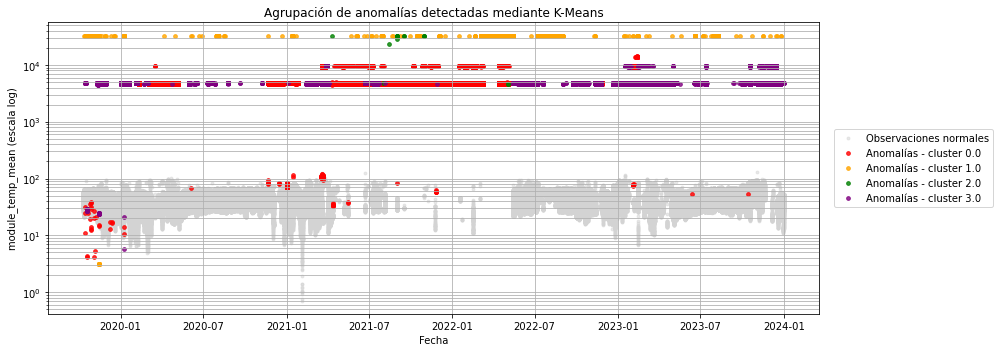

In [228]:
plt.figure(figsize=(14, 5))

# Máscara de observaciones normales
normal_points = results_cluster_val_df["is_anomaly"] == False

anomalies_val_df = results_cluster_val_df[results_cluster_val_df["is_anomaly"] == True]

# Observaciones normales en gris
plt.scatter(
    results_cluster_val_df.loc[normal_points, "datetime"],
    results_cluster_val_df.loc[normal_points, "module_temp_mean"],
    s=8,
    color="lightgray",
    alpha=0.5,
    label="Observaciones normales"
)

# Colores para los clusters de anomalías
cluster_colors = {
    0: "red",
    1: "orange",
    2: "green",
    3: "purple",
    4: "blue"
}

# Anomalías coloreadas por cluster
for cluster_id in sorted(anomalies_val_df["error_cluster"].unique()):
    cluster_data = anomalies_val_df[anomalies_val_df["error_cluster"] == cluster_id]

    plt.scatter(
        cluster_data["datetime"],
        cluster_data["module_temp_mean"],
        s=14,
        color=cluster_colors.get(cluster_id, None),
        alpha=0.8,
        label=f"Anomalías - cluster {cluster_id}"
    )

# Umbral de anomalía
plt.yscale("log")

plt.xlabel("Fecha")
plt.ylabel("module_temp_mean (escala log)")
plt.title("Agrupación de anomalías detectadas mediante K-Means")
plt.legend()
plt.grid(True, which="both")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)

plt.tight_layout()
plt.show()